# Uniform Surface Visuals
**Color scheme:** 🔴 Red = Brick | 🟢 Green = Grass | 🔵 Blue = Concrete

Covers all charts from the WSP presentation:
1. Pressure sensor time-series (left vs right)
2. Pressure sensor heatmaps
3. Step segmentation (total pressure with detected step boundaries)
4. Mid-stance pressure distribution box plots
5. Mid-stance segmentation (normalised forefoot vs heel)
6. Loading rate segmentation
7. Heel strike segmentation
8. Spectral energy / normalised stance profiles
9. Per-surface feature summary (statistical)
10. Confusion matrix (ML model results)
11. Step timeline prediction strip

In [1]:
# ── 0. Imports & Global Config ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis, f_oneway
import warnings; warnings.filterwarnings('ignore')

# ── UNIFORM COLOR PALETTE ────────────────────────────────────────────────────
COLORS = {
    'brick':    '#D32F2F',   # Red
    'grass':    '#388E3C',   # Green
    'concrete': '#1565C0',   # Blue
    'Brick':    '#D32F2F',
    'Grass':    '#388E3C',
    'Concrete': '#1565C0',
    'unknown':  '#9E9E9E',
}
SURFACES   = ['brick', 'grass', 'concrete']
SURF_NAMES = ['Brick', 'Grass', 'Concrete']

# ── Sensor groups (Stappone layout) ──────────────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

# ── Step detection parameters ────────────────────────────────────────────────
SMOOTH_WIN   = 11
SMOOTH_POLY  = 2
BIG_PEAK_DIST = 50
BIG_PEAK_PROM = 200
BIG_PEAK_HT   = 500
SAMPLING_HZ   = 62.5
HILL_WIN      = 10
MIN_DP        = 5

print('Config loaded. Colors:', {k: v for k, v in COLORS.items() if k in SURFACES})

Config loaded. Colors: {'brick': '#D32F2F', 'grass': '#388E3C', 'concrete': '#1565C0'}


In [2]:
# ── 1. Load Data ─────────────────────────────────────────────────────────────
brick_raw    = pd.read_csv('brick_dry.csv',    low_memory=False)
grass_raw    = pd.read_csv('grass_dry.csv',    low_memory=False)
concrete_raw = pd.read_csv('concrete_dry.csv', low_memory=False)

def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    for col in ALL_SENSORS + ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df['total_pressure'] = df[ALL_SENSORS].sum(axis=1)
    df['heel_pressure']  = df[HEEL_SENSORS].sum(axis=1)
    df['fore_pressure']  = df[FOREFOOT_SENSORS].sum(axis=1)
    return df

# Split by sole_id (1=right, 2=left)
datasets = {}
for name, raw in [('brick', brick_raw), ('grass', grass_raw), ('concrete', concrete_raw)]:
    datasets[name] = {
        'right': preprocess(raw[raw['sole_id'] == 1]),
        'left':  preprocess(raw[raw['sole_id'] == 2]),
    }
    for foot, df in datasets[name].items():
        print(f'{name:>8} {foot}: {len(df):5d} rows | {df["time_sec"].iloc[-1]:.1f}s')

   brick right:  1483 rows | 25.4s
   brick left:  1457 rows | 24.6s
   grass right:  1489 rows | 25.2s
   grass left:  1490 rows | 25.2s
concrete right:  2163 rows | 37.1s
concrete left:  2186 rows | 36.8s


In [3]:
# ── Helper: step detection ────────────────────────────────────────────────────
def find_step_peaks(df, sensors=None):
    """Return stance-peak indices from summed heel signal."""
    if sensors is None:
        sensors = HEEL_SENSORS
    y = sum(df[s].to_numpy(dtype=float) for s in sensors if s in df.columns)
    n  = len(y)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY: sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY+3) % 2 == 0 else 0)
    ys = savgol_filter(y, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(ys, distance=BIG_PEAK_DIST,
                           prominence=BIG_PEAK_PROM, height=BIG_PEAK_HT)
    return peaks

print('Step detection helper ready.')

Step detection helper ready.


---
## 📊 Plot 1 — Pressure Sensor Time-Series (Left vs Right)

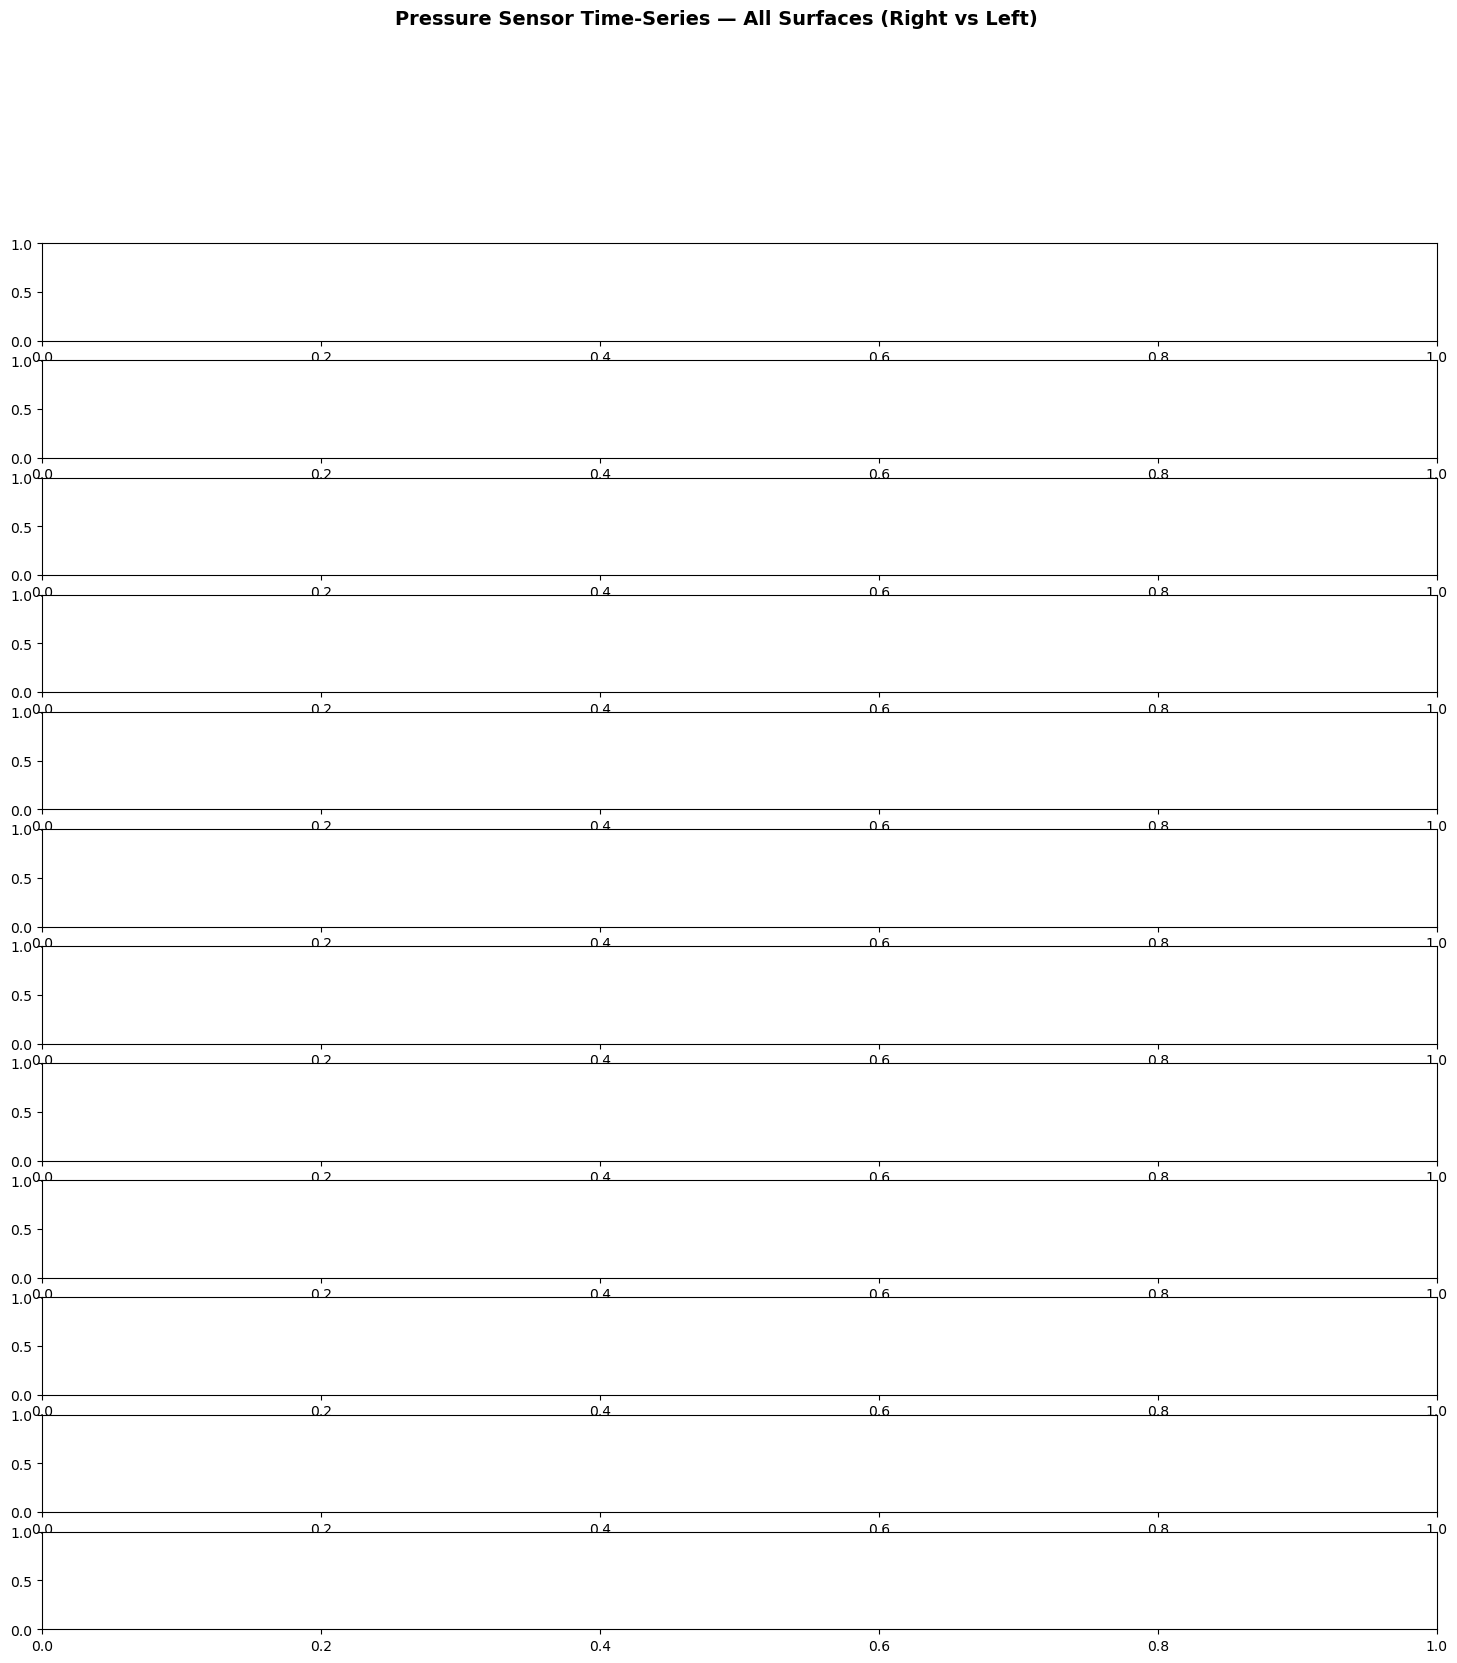

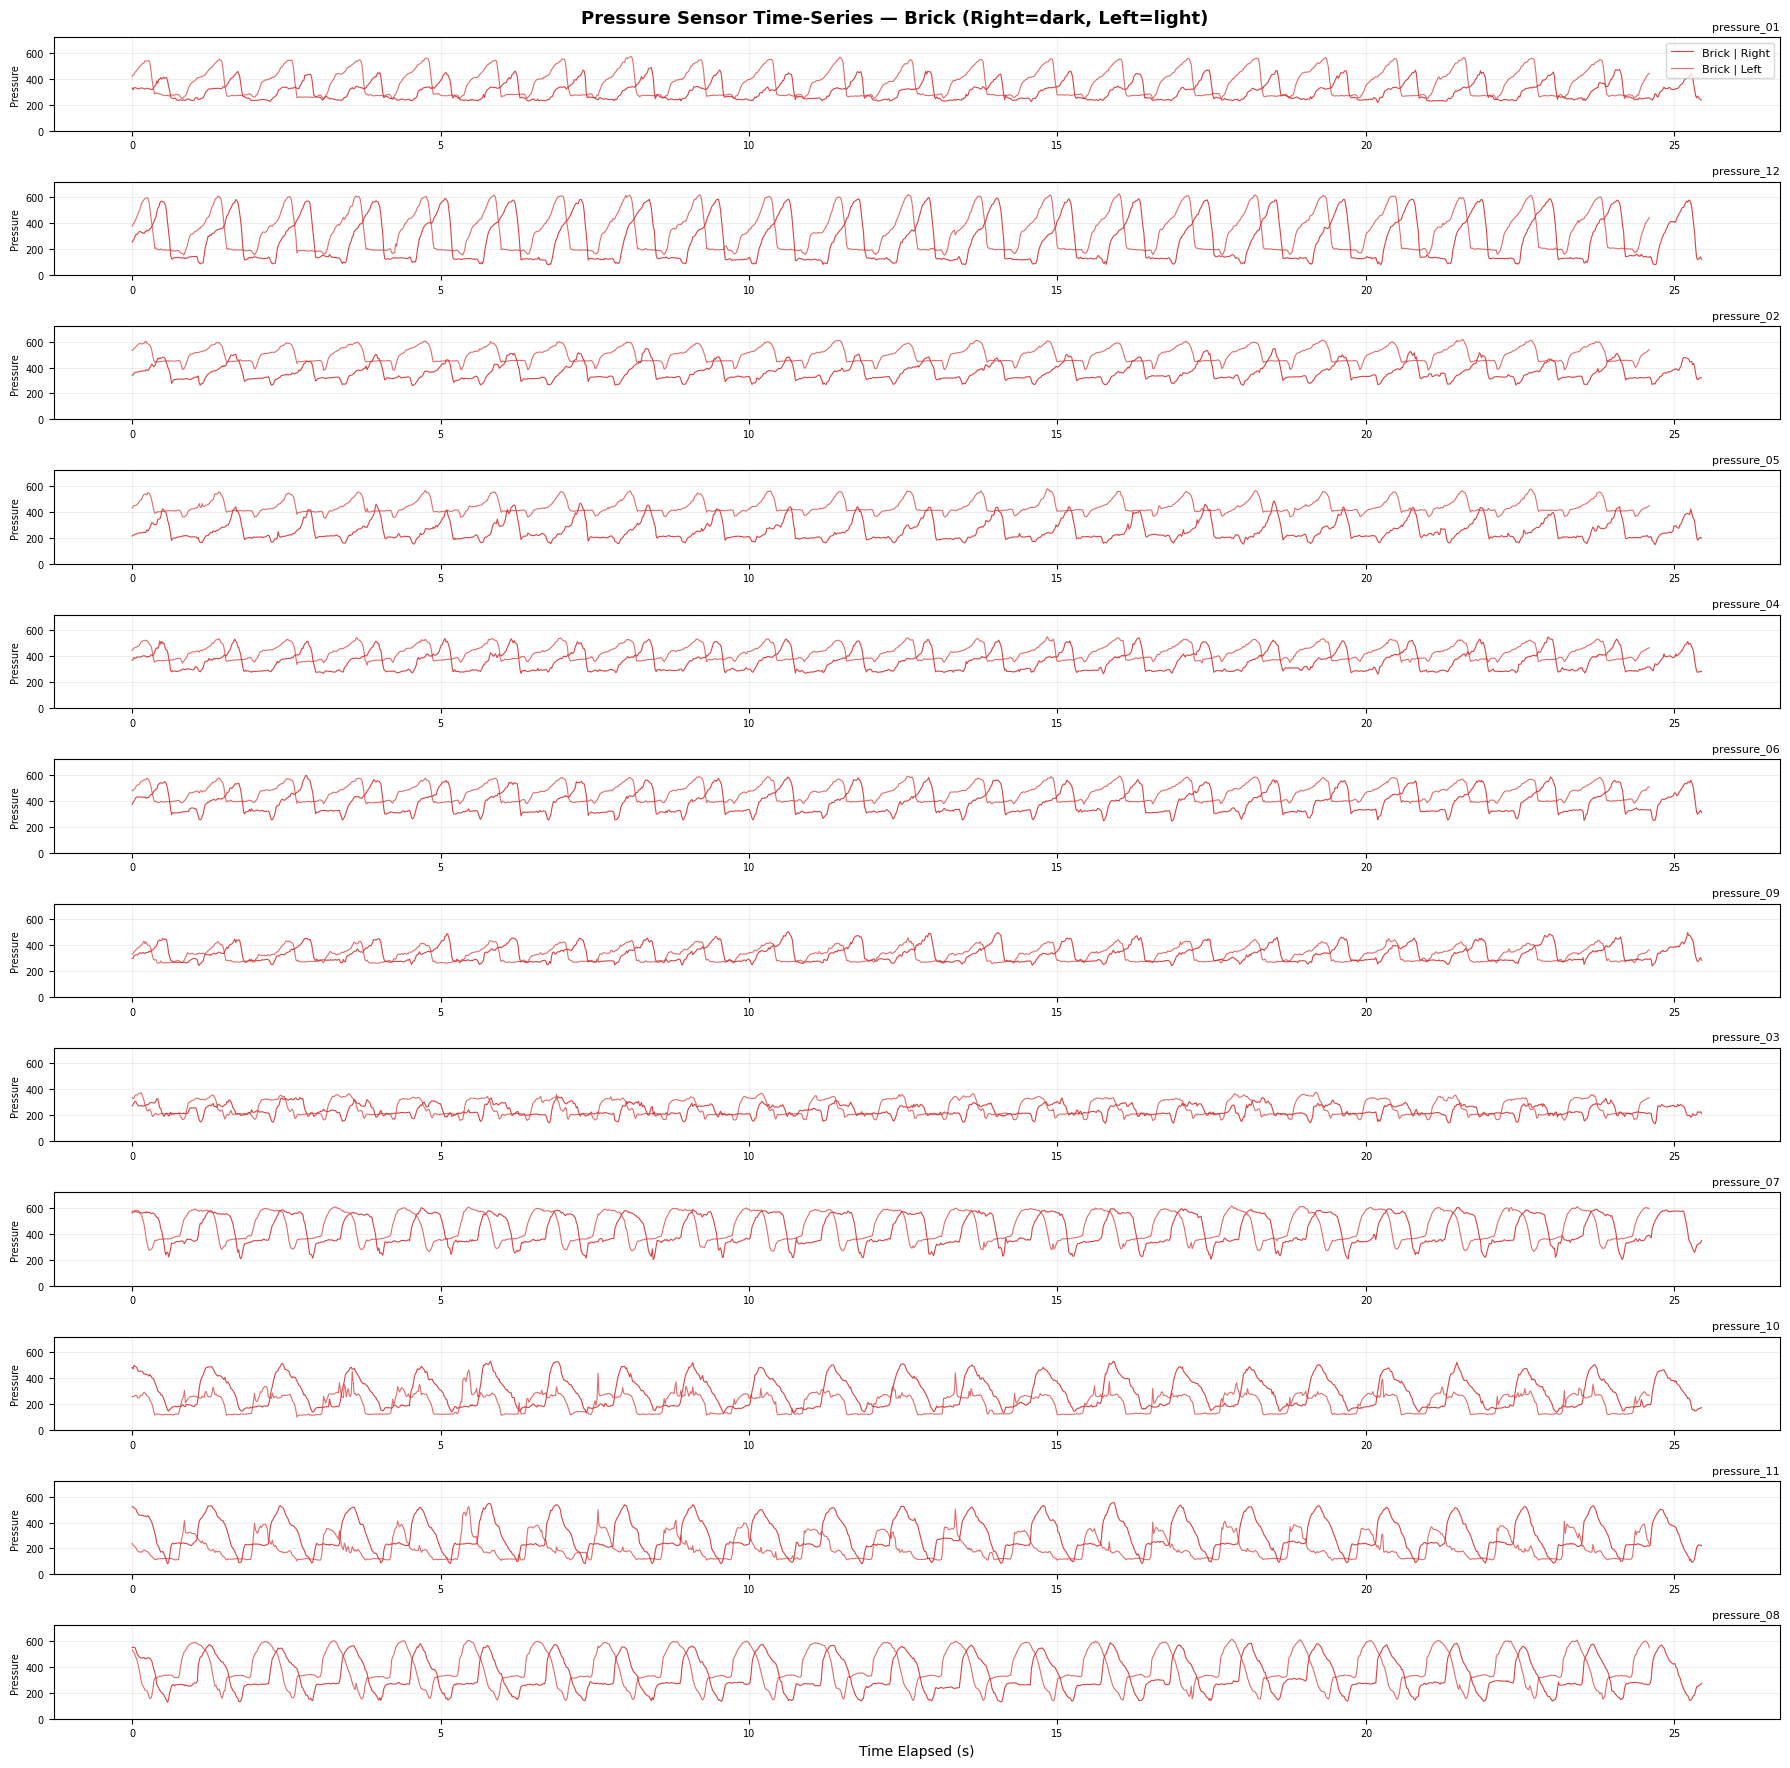

Saved → plot1_timeseries_brick.png


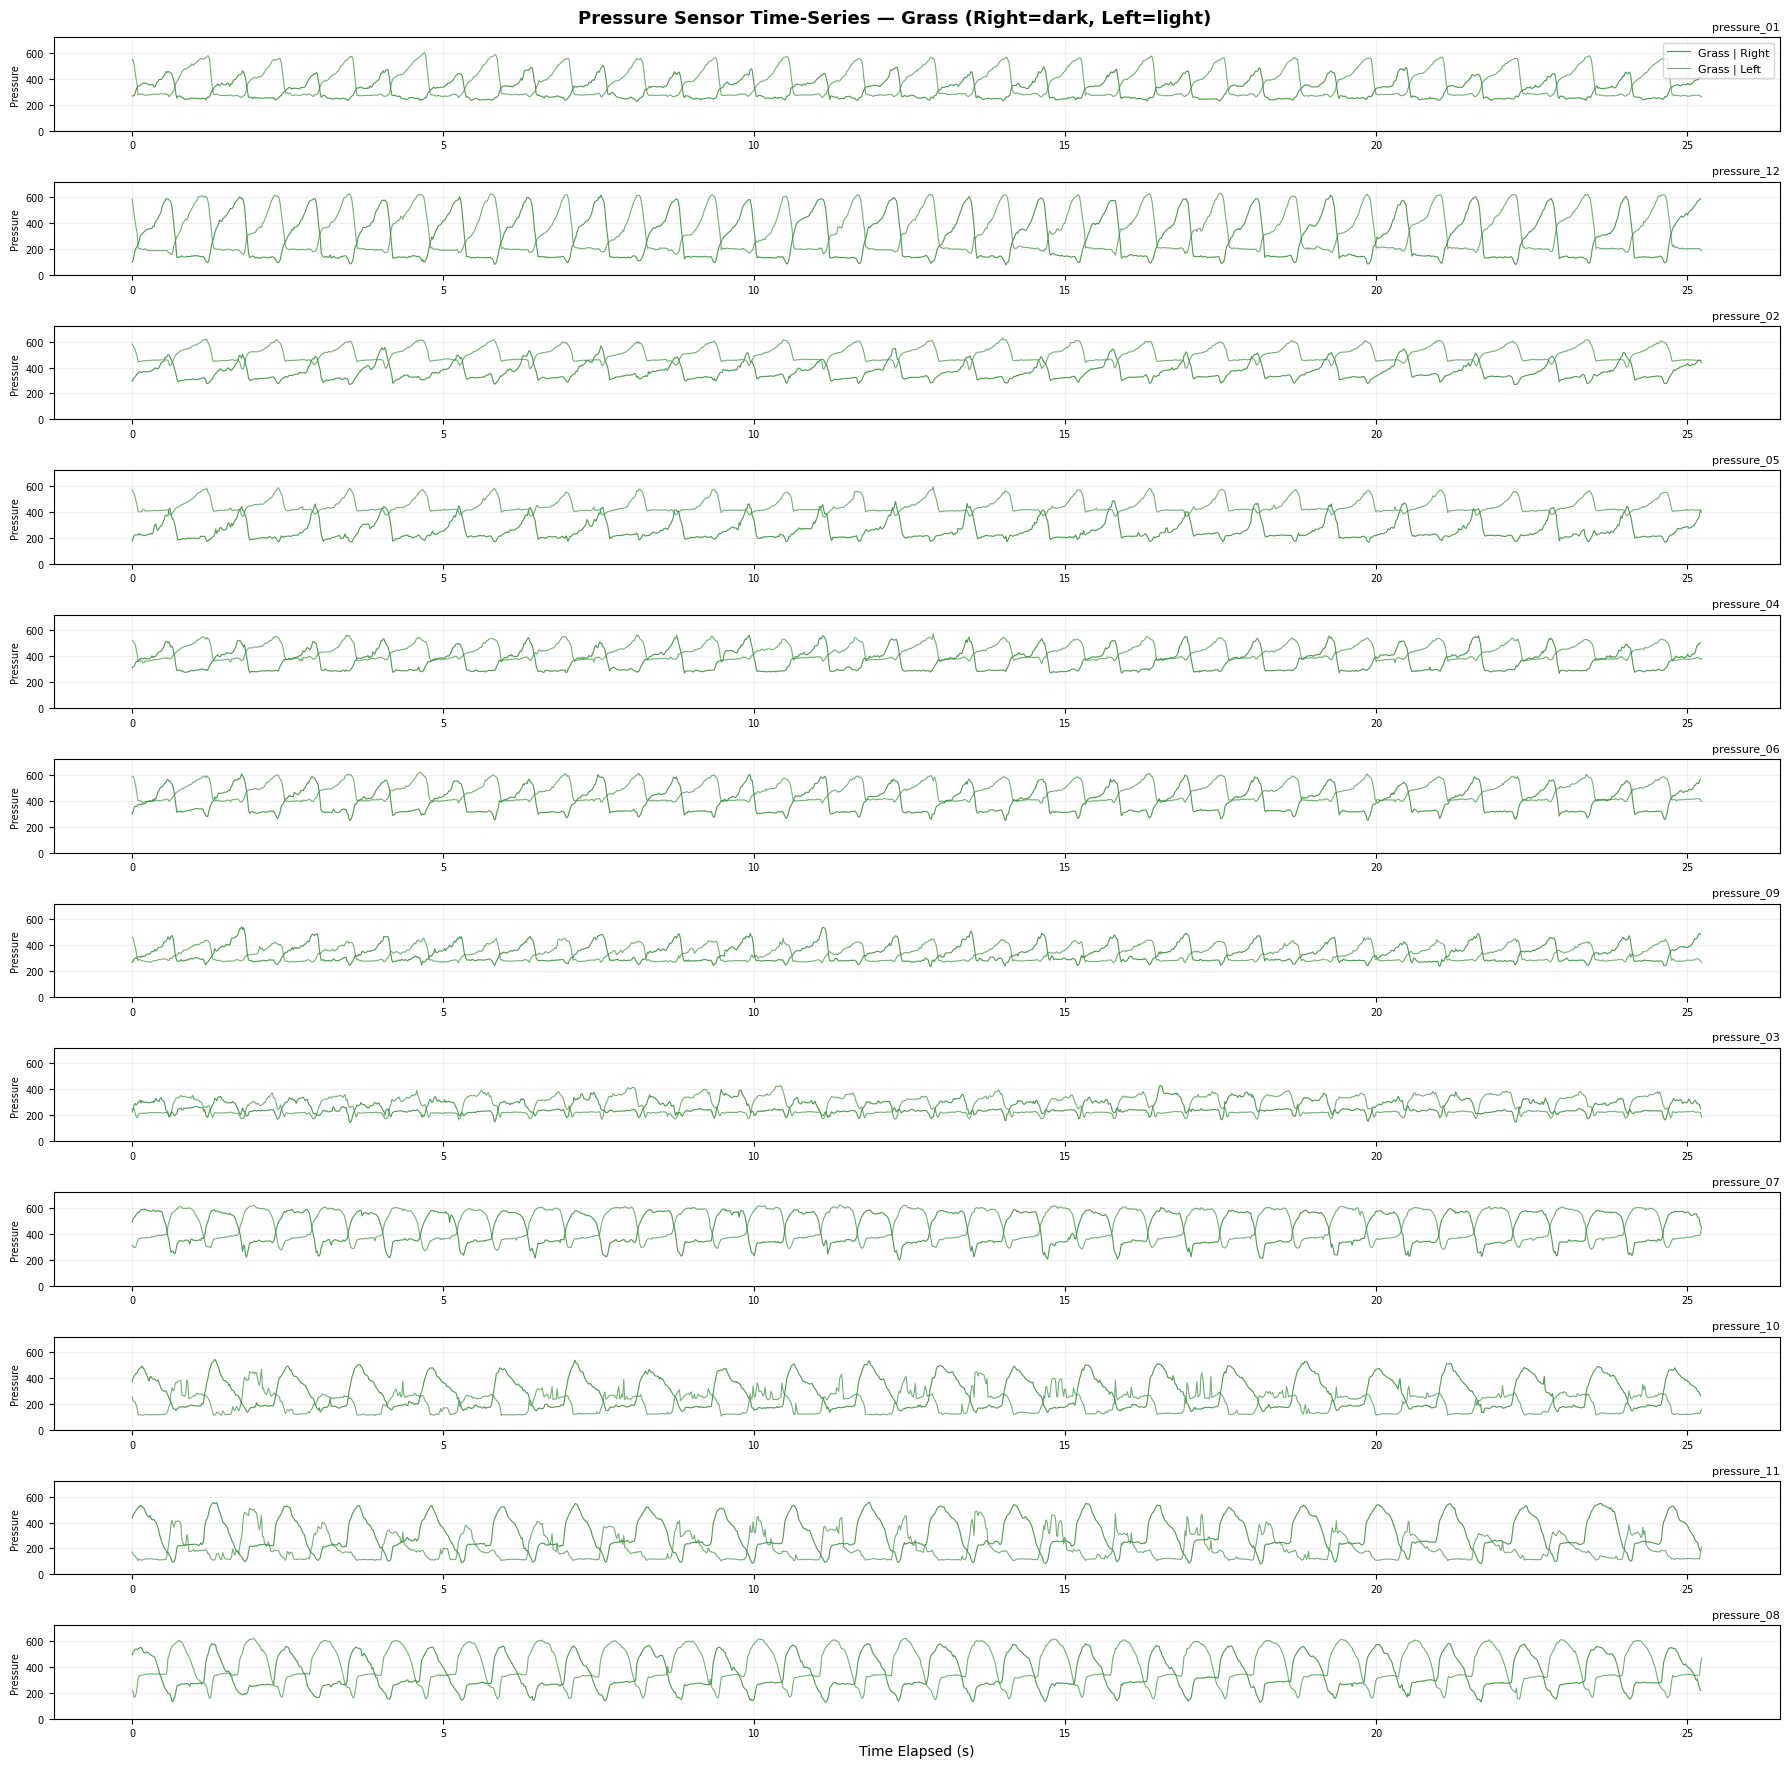

Saved → plot1_timeseries_grass.png


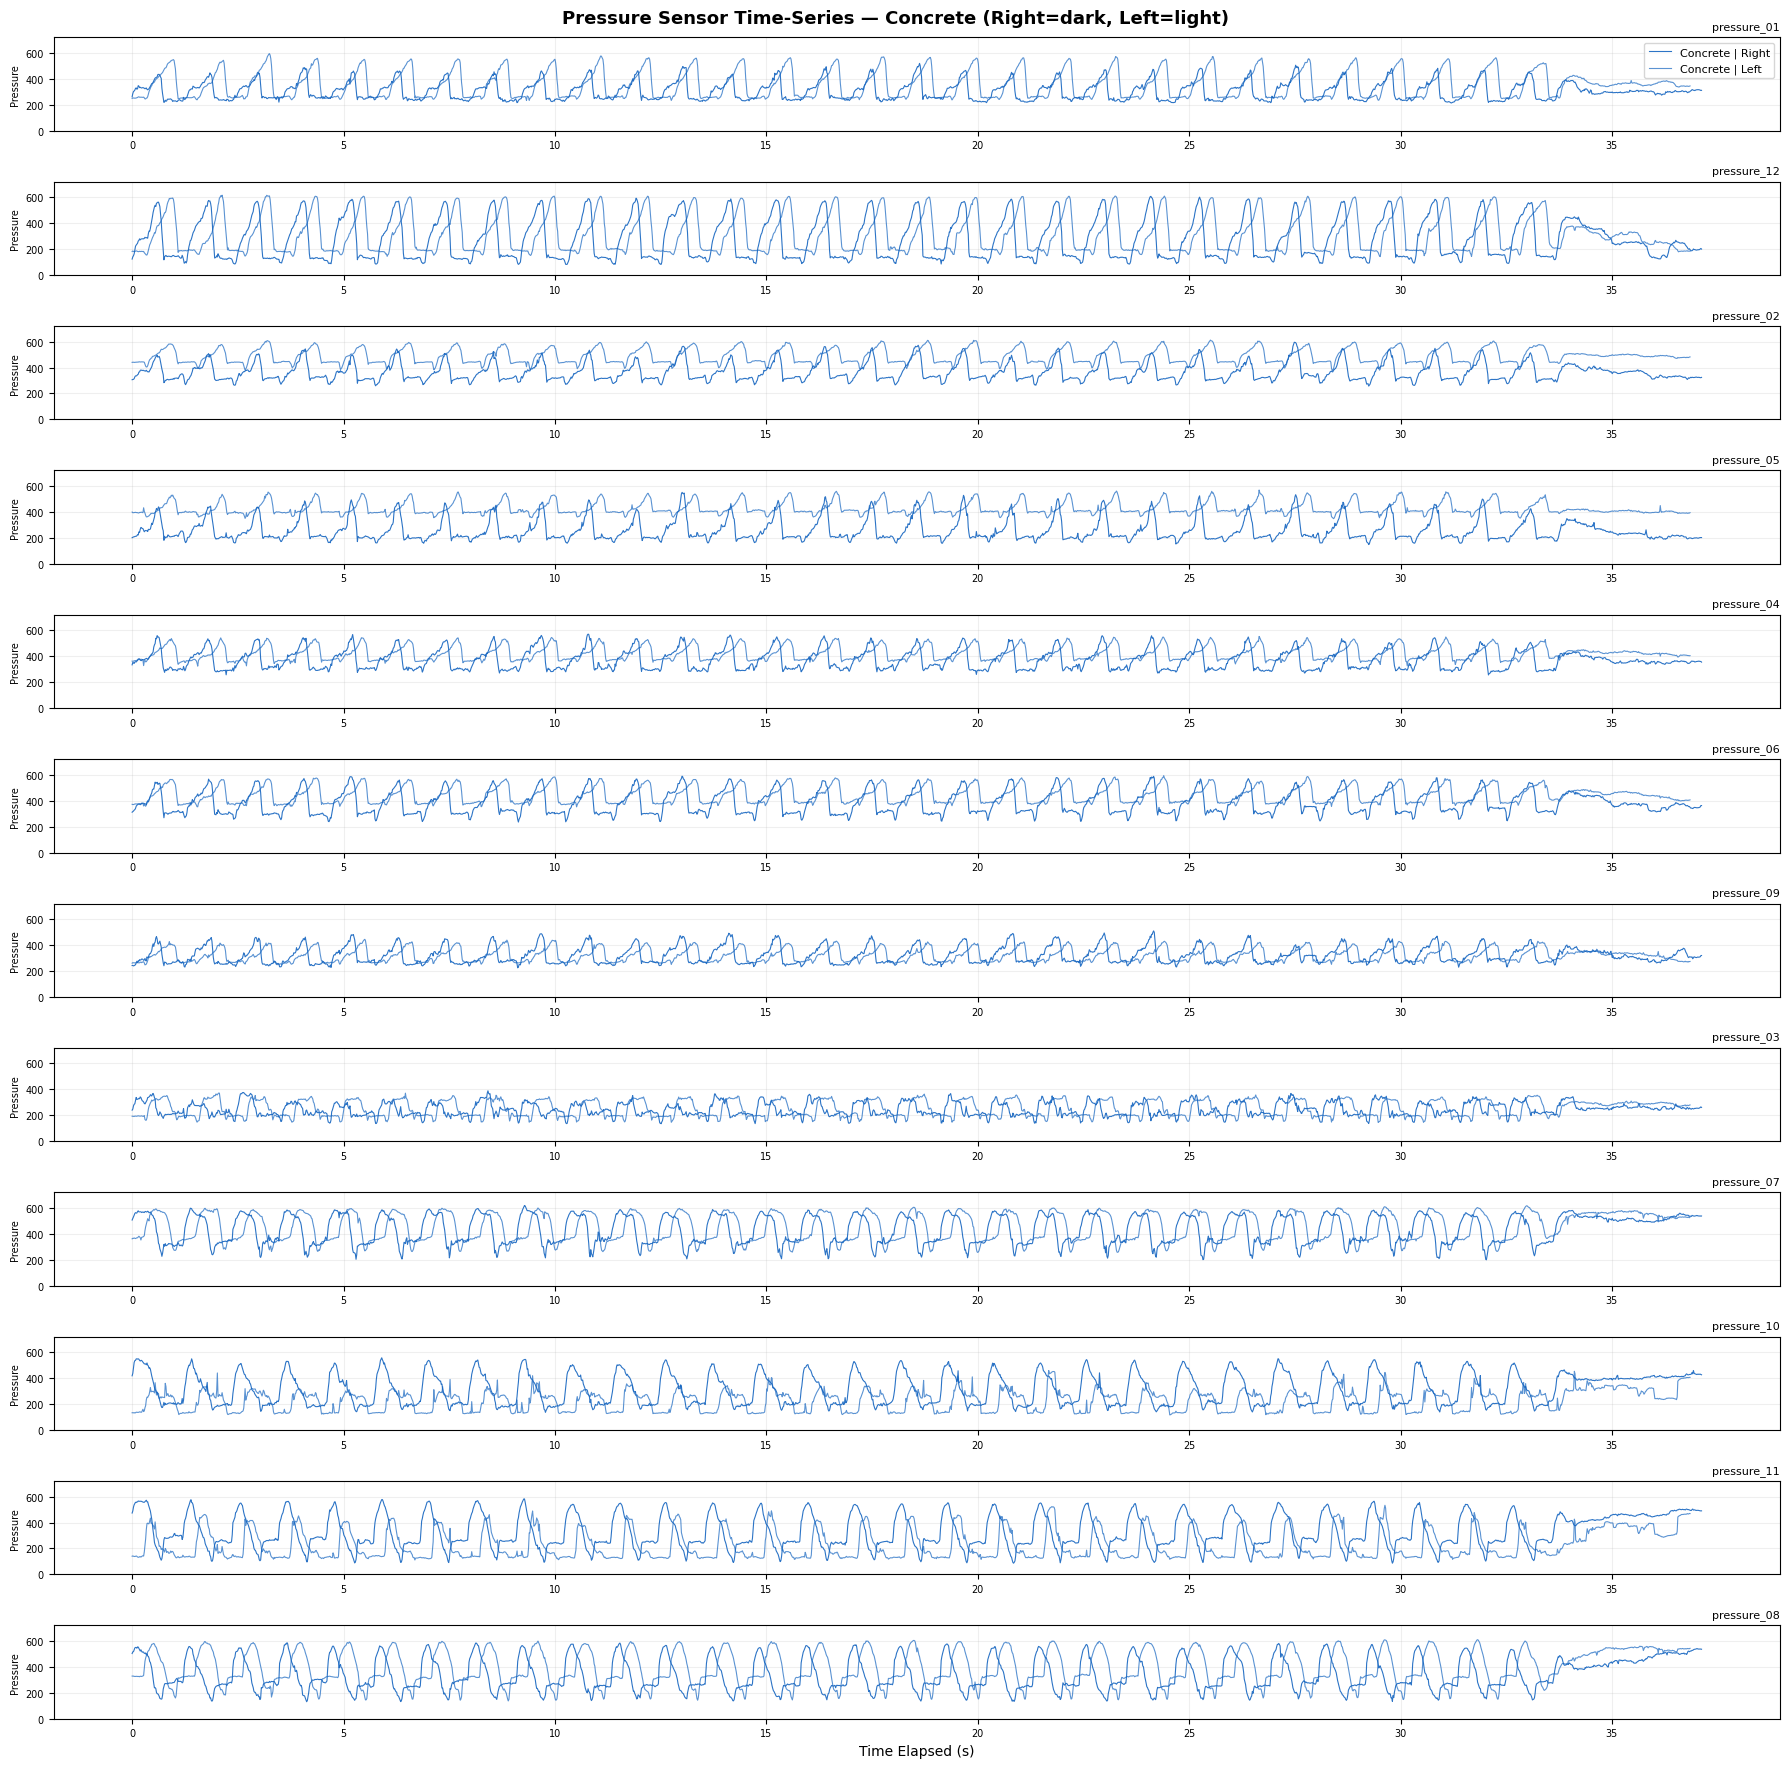

Saved → plot1_timeseries_concrete.png


In [4]:
# Sensor display order (matches original presentation)
SENSOR_ORDER = ['pressure_01','pressure_12','pressure_02','pressure_05',
                'pressure_04','pressure_06','pressure_09','pressure_03',
                'pressure_07','pressure_10','pressure_11','pressure_08']

fig, axes = plt.subplots(len(SENSOR_ORDER), 1,
                         figsize=(18, len(SENSOR_ORDER)*1.5), sharex=False)
fig.suptitle('Pressure Sensor Time-Series — All Surfaces (Right vs Left)',
             fontsize=14, fontweight='bold', y=1.01)

for surface in SURFACES:
    r_df = datasets[surface]['right']
    l_df = datasets[surface]['left']

    fig, axes = plt.subplots(len(SENSOR_ORDER), 1,
                             figsize=(18, len(SENSOR_ORDER)*1.5))
    fig.suptitle(f'Pressure Sensor Time-Series — {surface.capitalize()} (Right=dark, Left=light)',
                 fontsize=13, fontweight='bold')

    dark  = COLORS[surface]
    light = COLORS[surface] + '80'

    for ax, sensor in zip(axes, SENSOR_ORDER):
        if sensor in r_df.columns:
            ax.plot(r_df['time_sec'], r_df[sensor], color=dark,  lw=0.8,
                    label=f'{surface.capitalize()} | Right', alpha=0.9)
        if sensor in l_df.columns:
            ax.plot(l_df['time_sec'], l_df[sensor], color=light, lw=0.8,
                    label=f'{surface.capitalize()} | Left',  alpha=0.7)
        ax.set_ylabel('Pressure', fontsize=7)
        ax.set_title(sensor, fontsize=8, loc='right')
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)
        ax.set_ylim(0, 720)

    axes[-1].set_xlabel('Time Elapsed (s)')
    axes[0].legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'plot1_timeseries_{surface}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → plot1_timeseries_{surface}.png')

---
## 🌡️ Plot 2 — Pressure Sensor Heatmaps (Left vs Right)

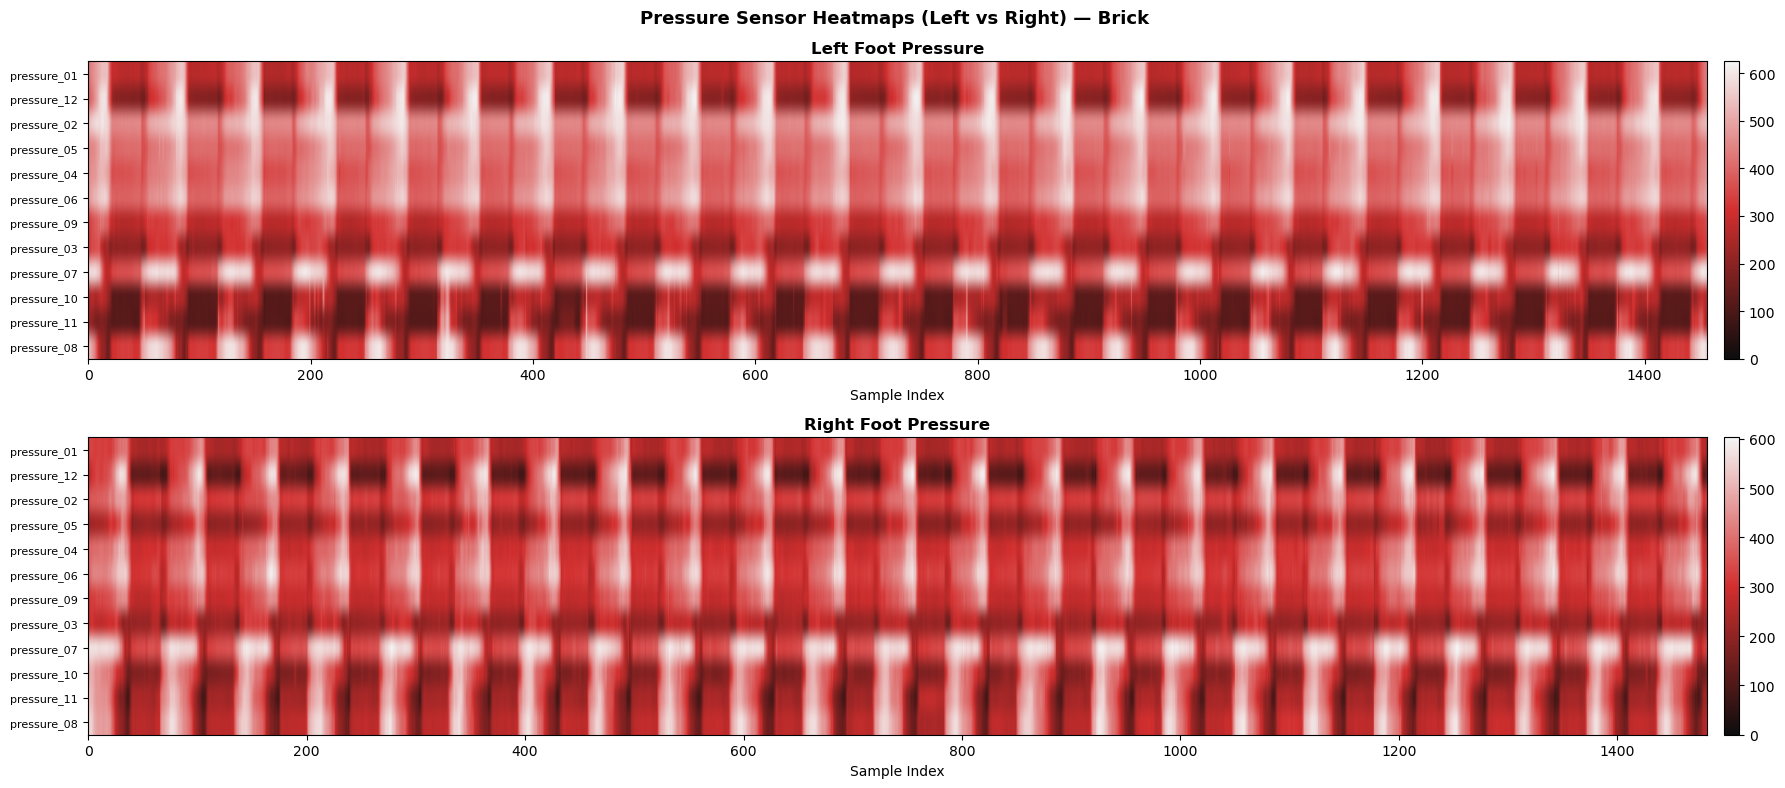

Saved → plot2_heatmap_brick.png


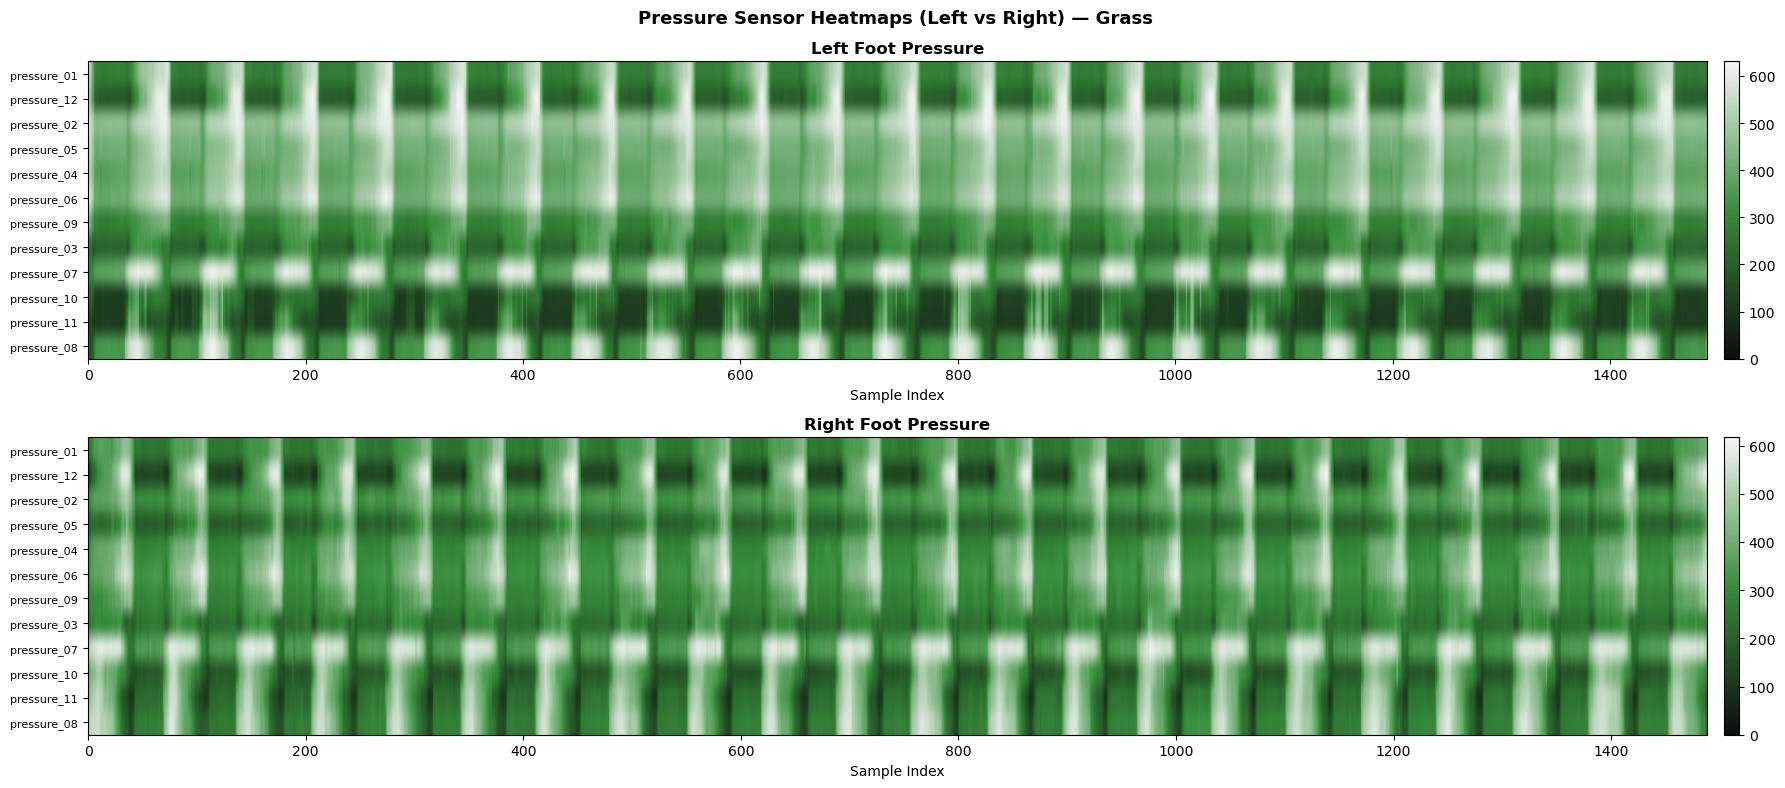

Saved → plot2_heatmap_grass.png


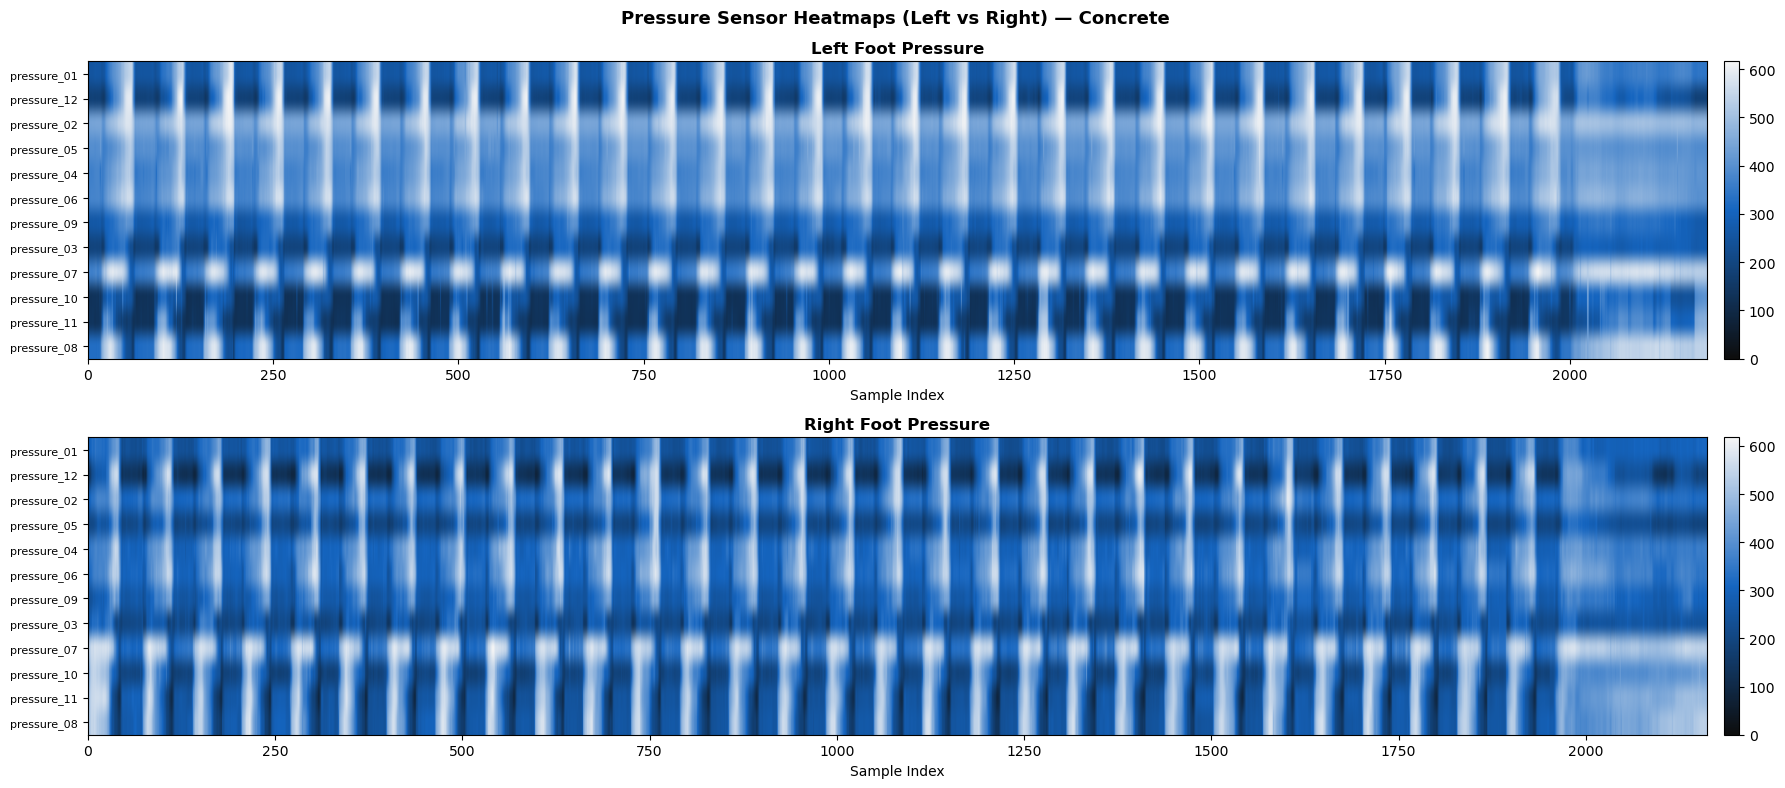

Saved → plot2_heatmap_concrete.png


In [5]:
for surface in SURFACES:
    r_df = datasets[surface]['right']
    l_df = datasets[surface]['left']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8))
    fig.suptitle(f'Pressure Sensor Heatmaps (Left vs Right) — {surface.capitalize()}',
                 fontsize=13, fontweight='bold')

    # Build a colour palette anchored to the surface colour
    from matplotlib.colors import LinearSegmentedColormap
    base = COLORS[surface]
    cmap = LinearSegmentedColormap.from_list(
        f'{surface}_cmap', ['#0d0d0d', base, '#f5f5f5'], N=256)

    for ax, df, title in [(ax1, l_df, 'Left Foot Pressure'),
                          (ax2, r_df, 'Right Foot Pressure')]:
        heat = df[SENSOR_ORDER].T.to_numpy(dtype=float)
        im = ax.imshow(heat, aspect='auto', cmap=cmap,
                       vmin=0, vmax=heat.max())
        ax.set_yticks(range(len(SENSOR_ORDER)))
        ax.set_yticklabels(SENSOR_ORDER, fontsize=8)
        ax.set_xlabel('Sample Index')
        ax.set_title(title, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)

    plt.tight_layout()
    plt.savefig(f'plot2_heatmap_{surface}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → plot2_heatmap_{surface}.png')

---
## 👣 Plot 3 — Step Segmentation (Total Pressure + Detected Boundaries)

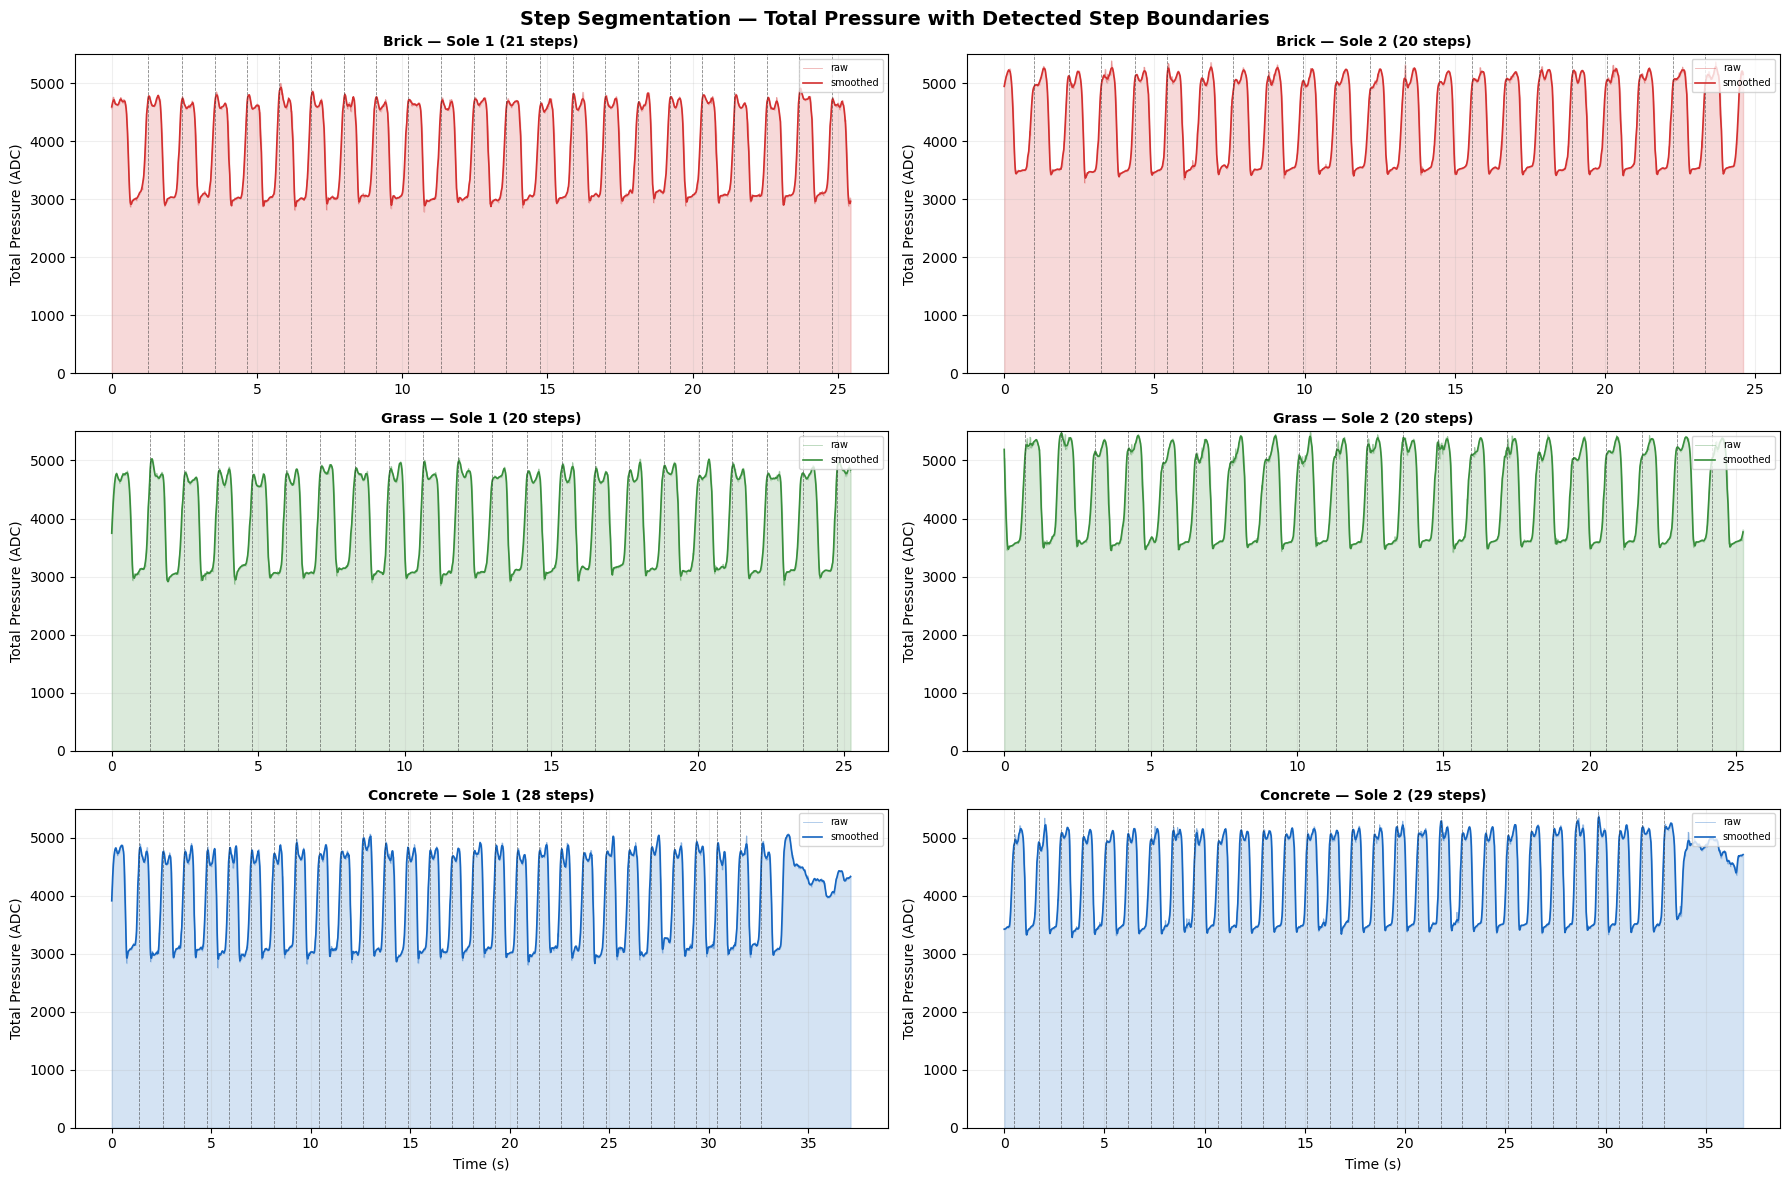

Saved → plot3_step_segmentation.png


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Step Segmentation — Total Pressure with Detected Step Boundaries',
             fontsize=14, fontweight='bold')

for row, surface in enumerate(SURFACES):
    for col, foot in enumerate(['right', 'left']):
        ax  = axes[row][col]
        df  = datasets[surface][foot]
        t   = df['time_sec'].values
        tp  = df['total_pressure'].values

        # Smooth total pressure
        n  = len(tp)
        sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
        if sw % 2 == 0: sw -= 1
        if sw < 3: sw = 3
        tp_sm = savgol_filter(tp, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))

        peaks = find_step_peaks(df)
        n_steps = max(len(peaks) - 1, 0)

        col_main = COLORS[surface]
        ax.fill_between(t, tp, alpha=0.18, color=col_main)
        ax.plot(t, tp,    color=col_main + '60', lw=0.6, label='raw')
        ax.plot(t, tp_sm, color=col_main,        lw=1.2, label='smoothed')

        for p in peaks:
            ax.axvline(t[p], color='#333333', lw=0.6, ls='--', alpha=0.6)

        sole_num = 1 if foot == 'right' else 2
        ax.set_title(f'{surface.capitalize()} — Sole {sole_num} ({n_steps} steps)',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('Total Pressure (ADC)')
        ax.set_ylim(0, 5500)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, loc='upper right')

axes[2][0].set_xlabel('Time (s)')
axes[2][1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('plot3_step_segmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot3_step_segmentation.png')

---
## 📦 Plot 4 — Mid-Stance Pressure Distribution Box Plots

In [7]:
from scipy.stats import entropy as scipy_entropy

def compute_midstance_features(df):
    """Extract Shannon entropy and Spatial CV at midstance for each step."""
    peaks = find_step_peaks(df)
    rows  = []
    for i in range(len(peaks) - 1):
        p1, p2   = peaks[i], peaks[i+1]
        window   = df.iloc[p1:p2]
        mid_idx  = p1 + (p2 - p1) // 2
        mid_row  = df.iloc[mid_idx][ALL_SENSORS].values.astype(float)
        mid_row  = np.clip(mid_row, 1e-6, None)
        mid_norm = mid_row / mid_row.sum()
        H   = scipy_entropy(mid_norm, base=2)
        cv  = mid_row.std() / (mid_row.mean() + 1e-9)
        rows.append({'H_spatial': H, 'spatial_cv': cv})
    return pd.DataFrame(rows)

midstance_data = {}
for surface in SURFACES:
    frames = []
    for foot in ['right', 'left']:
        f = compute_midstance_features(datasets[surface][foot])
        frames.append(f)
    midstance_data[surface] = pd.concat(frames, ignore_index=True)
    print(f'{surface}: {len(midstance_data[surface])} midstance observations')

brick: 41 midstance observations
grass: 40 midstance observations
concrete: 57 midstance observations


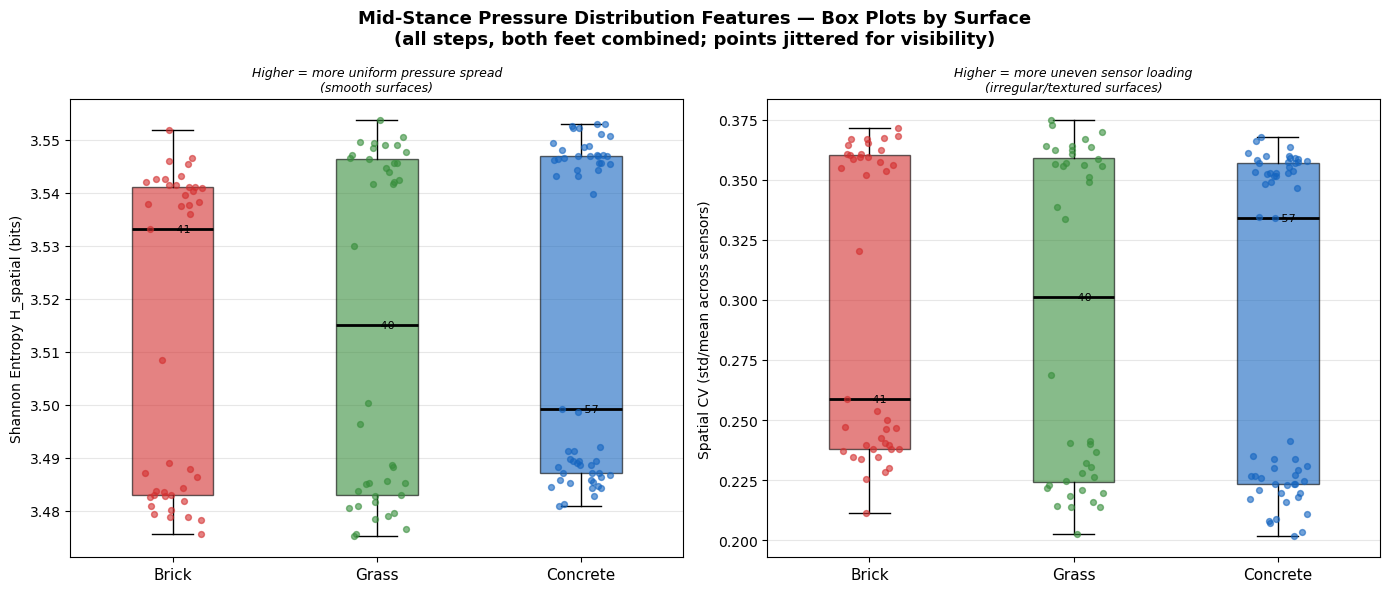

Saved → plot4_midstance_boxplots.png


In [8]:
import numpy.random as npr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Mid-Stance Pressure Distribution Features — Box Plots by Surface\n'
             '(all steps, both feet combined; points jittered for visibility)',
             fontsize=13, fontweight='bold')

positions = range(len(SURFACES))
for ax, metric, ylabel, subtitle in [
    (ax1, 'H_spatial',  'Shannon Entropy H_spatial (bits)',
     'Higher = more uniform pressure spread\n(smooth surfaces)'),
    (ax2, 'spatial_cv', 'Spatial CV (std/mean across sensors)',
     'Higher = more uneven sensor loading\n(irregular/textured surfaces)'),
]:
    data_list  = [midstance_data[s][metric].dropna().values for s in SURFACES]
    bp = ax.boxplot(data_list, positions=list(positions),
                    patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', lw=2))

    for patch, surf in zip(bp['boxes'], SURFACES):
        patch.set_facecolor(COLORS[surf])
        patch.set_alpha(0.6)

    for i, (surf, vals) in enumerate(zip(SURFACES, data_list)):
        jitter = npr.default_rng(42).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=COLORS[surf], s=18, alpha=0.6, zorder=3)
        ax.text(i, np.median(vals), f' {len(vals)}',
                ha='left', va='center', fontsize=8)

    ax.set_xticks(list(positions))
    ax.set_xticklabels(SURF_NAMES, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_title(subtitle, fontsize=9, style='italic')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot4_midstance_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot4_midstance_boxplots.png')

---
## ⚖️ Plot 5 — Mid-Stance Segmentation (Normalised Forefoot vs Heel)

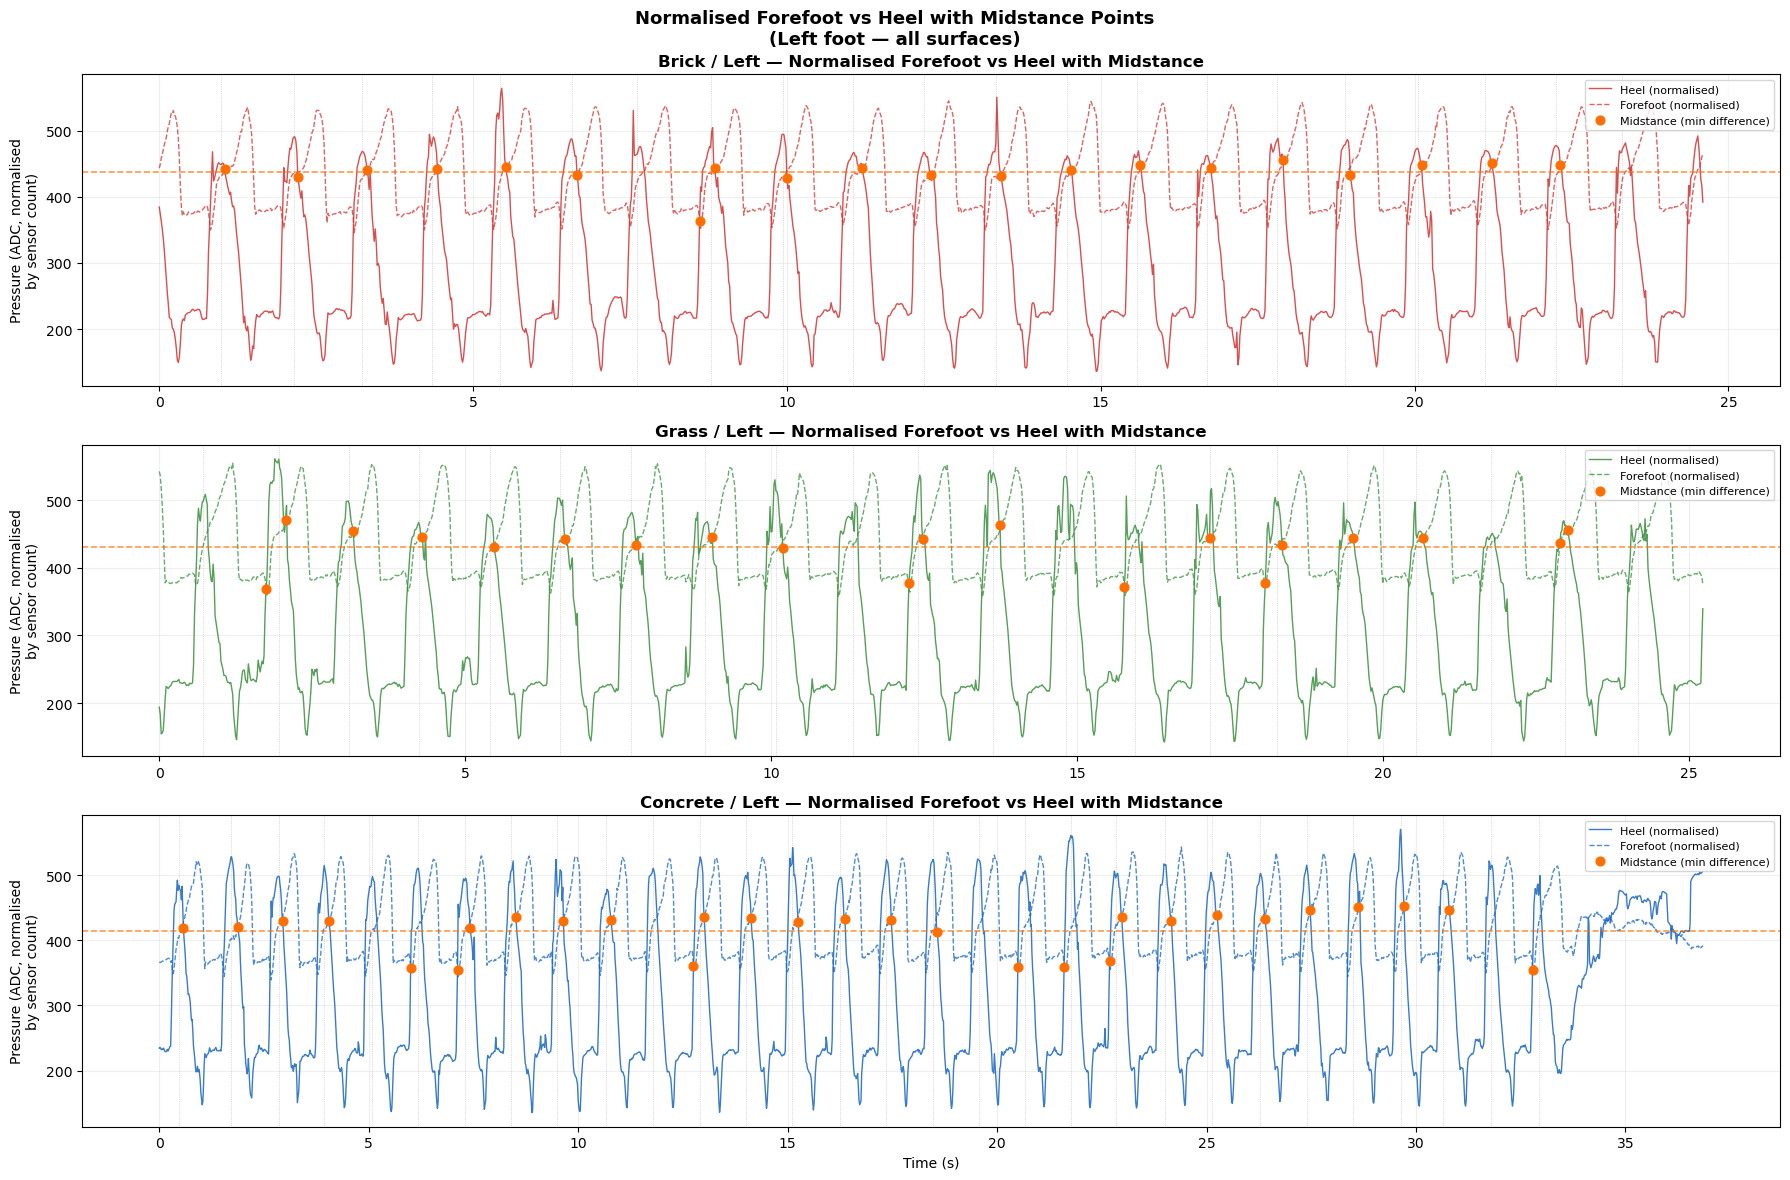

Saved → plot5_midstance_segmentation.png


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle('Normalised Forefoot vs Heel with Midstance Points\n'
             '(Left foot — all surfaces)',
             fontsize=13, fontweight='bold')

for ax, surface in zip(axes, SURFACES):
    df   = datasets[surface]['left']
    t    = df['time_sec'].values
    heel = df[HEEL_SENSORS].sum(axis=1).values / len(HEEL_SENSORS)
    fore = df[FOREFOOT_SENSORS].sum(axis=1).values / len(FOREFOOT_SENSORS)

    peaks = find_step_peaks(df)

    c = COLORS[surface]
    # heel = reddish tint of surface colour; fore = lighter blue-ish
    ax.plot(t, heel, color=c,        lw=1.0, alpha=0.85, label='Heel (normalised)')
    ax.plot(t, fore, color=c + 'AA', lw=1.0, alpha=0.75, label='Forefoot (normalised)', ls='--')

    # Mark midstance (minimum |heel - fore| within each step)
    mid_times, mid_vals = [], []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        diff   = np.abs(heel[p1:p2] - fore[p1:p2])
        m_rel  = int(np.argmin(diff))
        m_abs  = p1 + m_rel
        mid_times.append(t[m_abs])
        mid_vals.append(heel[m_abs])

    ax.scatter(mid_times, mid_vals, color='#FF6F00', s=40, zorder=5,
               label='Midstance (min difference)')

    # Dashed mean midstance line
    if mid_vals:
        ax.axhline(np.mean(mid_vals), color='#FF6F00', ls='--', lw=1.2, alpha=0.7)

    for p in peaks:
        ax.axvline(t[p], color='#555', lw=0.5, ls=':', alpha=0.4)

    ax.set_title(f'{surface.capitalize()} / Left — Normalised Forefoot vs Heel with Midstance',
                 fontweight='bold')
    ax.set_ylabel('Pressure (ADC, normalised\nby sensor count)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('plot5_midstance_segmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot5_midstance_segmentation.png')

---
## 📈 Plot 6 — Loading Rate Segmentation

In [10]:
def compute_loading_rates(df):
    """Per-step loading rate (pressure units/s) for sensor 11 (heel)."""
    target = 'pressure_11'
    if target not in df.columns:
        return []
    sig    = df[target].values.astype(float)
    t      = df['time_sec'].values
    peaks  = find_step_peaks(df)
    rates  = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        seg    = sig[p1:p2]
        hlo    = int(np.argmin(seg))
        hill   = seg[hlo:min(hlo + HILL_WIN, len(seg))]
        if len(hill) < 2: continue
        lps, _ = find_peaks(hill, prominence=1)
        hhi    = lps[0] if len(lps) else int(np.argmax(hill[1:])) + 1
        dp     = hill[hhi] - hill[0]
        dt_idx = hhi
        if dp < MIN_DP or dt_idx == 0: continue
        dt  = (t[p1 + hlo + dt_idx] - t[p1 + hlo]) if dt_idx > 0 else 1e-9
        if dt < 1e-9: continue
        rates.append(dp / dt)
    return rates

# Collect loading rates
lr_data = {}
for surface in SURFACES:
    for foot in ['right', 'left']:
        key = f'{surface}_{foot}'
        lr_data[key] = compute_loading_rates(datasets[surface][foot])
        print(f'{key}: {len(lr_data[key])} steps')

brick_right: 21 steps
brick_left: 19 steps
grass_right: 20 steps
grass_left: 20 steps
concrete_right: 28 steps
concrete_left: 26 steps


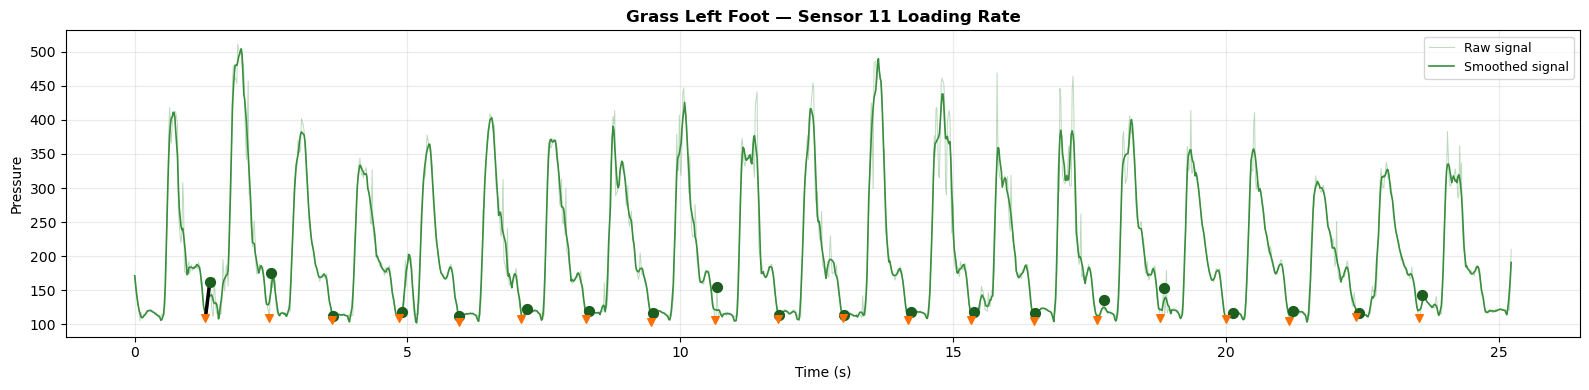

In [11]:
# ── 6a  Sensor 11 raw signal with peaks/contacts (left grass example) ────────
fig_ex, ax_ex = plt.subplots(figsize=(16, 4))
df_ex  = datasets['grass']['left']
t_ex   = df_ex['time_sec'].values
sig_ex = df_ex['pressure_11'].values.astype(float)
n  = len(sig_ex)
sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
if sw % 2 == 0: sw -= 1
if sw < 3: sw = 3
sig_sm = savgol_filter(sig_ex, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))

peaks_ex = find_step_peaks(df_ex)
ax_ex.plot(t_ex, sig_ex, color=COLORS['grass'] + '55', lw=0.7, label='Raw signal')
ax_ex.plot(t_ex, sig_sm, color=COLORS['grass'],        lw=1.2, label='Smoothed signal')

# Mark first-hill peaks and contacts per step
for i in range(len(peaks_ex) - 1):
    p1, p2 = peaks_ex[i], peaks_ex[i+1]
    seg    = sig_ex[p1:p2]
    hlo    = int(np.argmin(seg))
    hill   = seg[hlo:min(hlo + HILL_WIN, len(seg))]
    lps, _ = find_peaks(hill, prominence=1)
    hhi    = lps[0] if len(lps) else int(np.argmax(hill[1:])) + 1
    ax_ex.scatter(t_ex[p1 + hlo + hhi], sig_ex[p1 + hlo + hhi],
                  color='#1B5E20', s=50, zorder=5)
    ax_ex.scatter(t_ex[p1 + hlo], sig_ex[p1 + hlo],
                  color='#FF6F00', s=30, zorder=5, marker='v')
    if i == 0:
        # Draw slope line
        ax_ex.plot([t_ex[p1 + hlo], t_ex[p1 + hlo + hhi]],
                   [sig_ex[p1 + hlo], sig_ex[p1 + hlo + hhi]],
                   'k-', lw=2.5, zorder=4)

ax_ex.set_title('Grass Left Foot — Sensor 11 Loading Rate',
                fontsize=12, fontweight='bold')
ax_ex.set_xlabel('Time (s)')
ax_ex.set_ylabel('Pressure')
ax_ex.legend(fontsize=9)
ax_ex.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('plot6a_loading_rate_signal.png', dpi=120, bbox_inches='tight')
plt.show()

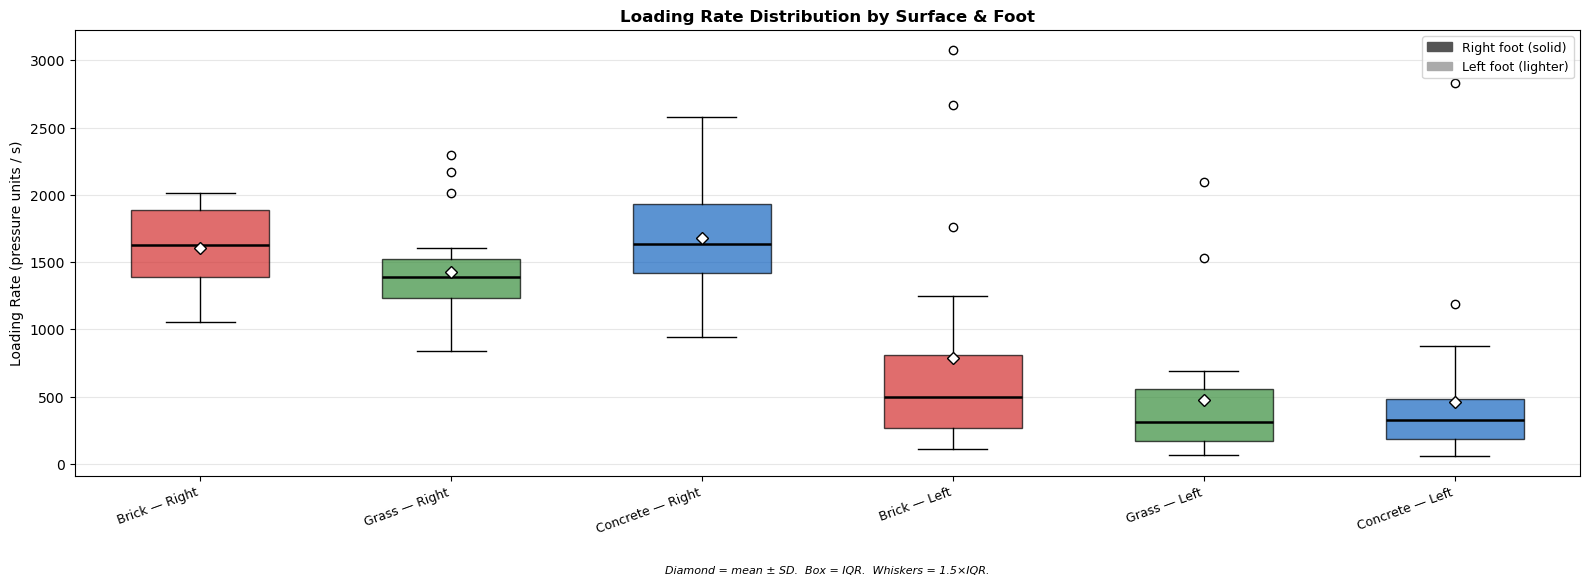

Saved → plot6b_loading_rate_boxplots.png


In [12]:
# ── 6b  Loading rate distribution box plots ───────────────────────────────────
keys_right = [f'{s}_right' for s in SURFACES]
keys_left  = [f'{s}_left'  for s in SURFACES]
all_keys   = keys_right + keys_left
labels     = ([f'{s.capitalize()} — Right' for s in SURFACES] +
              [f'{s.capitalize()} — Left'  for s in SURFACES])
colors_plot = ([COLORS[s] for s in SURFACES] +
               [COLORS[s] + 'AA' for s in SURFACES])

fig, ax = plt.subplots(figsize=(16, 6))
data_lr = [lr_data[k] for k in all_keys]
bp = ax.boxplot(data_lr, patch_artist=True, widths=0.55,
                medianprops=dict(color='black', lw=1.8),
                meanprops=dict(marker='D', markersize=6, markerfacecolor='white',
                               markeredgecolor='black'),
                showmeans=True)

for patch, col in zip(bp['boxes'], colors_plot):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(all_keys) + 1))
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Loading Rate (pressure units / s)')
ax.set_title('Loading Rate Distribution by Surface & Foot',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

right_patch = mpatches.Patch(color='#555', label='Right foot (solid)')
left_patch  = mpatches.Patch(color='#AAA', label='Left foot (lighter)')
ax.legend(handles=[right_patch, left_patch], fontsize=9)

ax.text(0.5, -0.22,
        'Diamond = mean ± SD.  Box = IQR.  Whiskers = 1.5×IQR.',
        ha='center', transform=ax.transAxes, fontsize=8, style='italic')

plt.tight_layout()
plt.savefig('plot6b_loading_rate_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot6b_loading_rate_boxplots.png')

---
## 🦶 Plot 7 — Heel Strike Segmentation

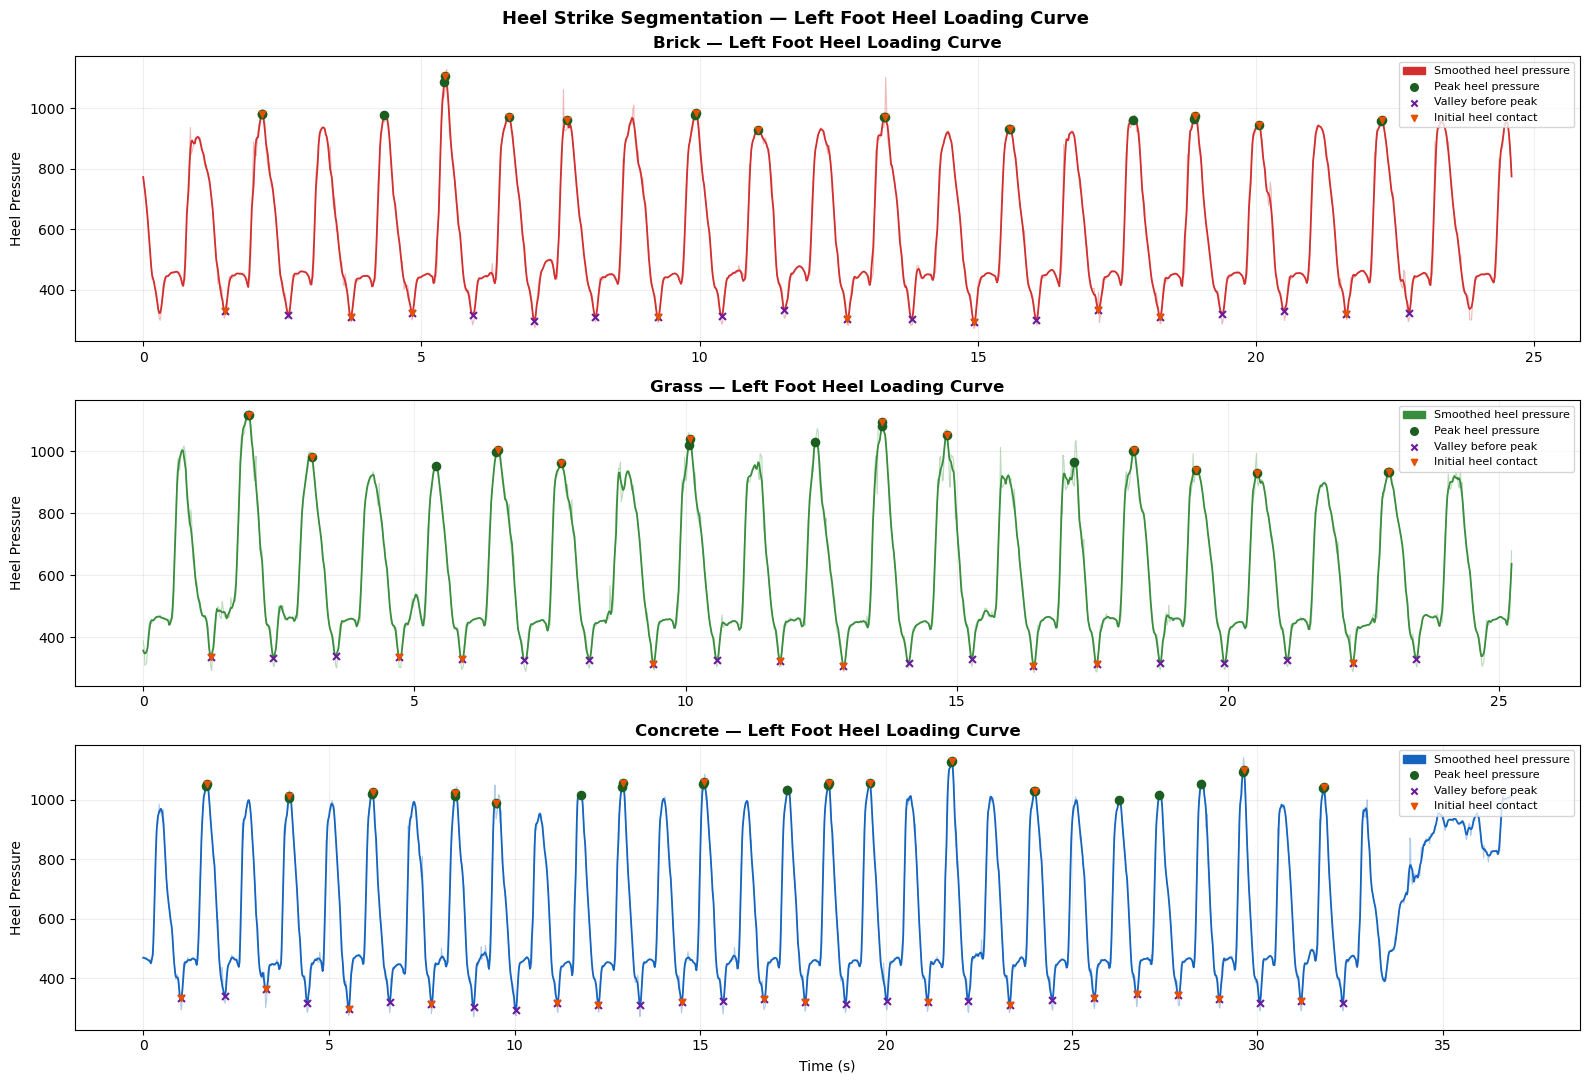

Saved → plot7_heel_strike.png


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11))
fig.suptitle('Heel Strike Segmentation — Left Foot Heel Loading Curve',
             fontsize=13, fontweight='bold')

for ax, surface in zip(axes, SURFACES):
    df  = datasets[surface]['left']
    t   = df['time_sec'].values
    hp  = df['heel_pressure'].values.astype(float)

    n  = len(hp)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw < 3: sw = 3
    hp_sm = savgol_filter(hp, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))

    peaks = find_step_peaks(df)
    c = COLORS[surface]

    ax.plot(t, hp,    color=c + '55', lw=0.8, label='Raw heel pressure')
    ax.plot(t, hp_sm, color=c,        lw=1.3, label='Smoothed heel pressure')

    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        seg    = hp_sm[p1:p2]
        valley = p1 + int(np.argmin(seg))
        peak_p = p1 + int(np.argmax(seg))
        # contact: local min before peak
        pre = seg[:int(np.argmax(seg))]
        contact = p1 + (int(np.argmin(pre)) if len(pre) > 0 else 0)

        ax.scatter(t[peak_p], hp_sm[peak_p],
                   color='#1B5E20', s=35, zorder=5)
        ax.scatter(t[valley], hp_sm[valley],
                   color='#6A1B9A', s=25, marker='x', zorder=5, linewidths=1.5)
        ax.scatter(t[contact], hp_sm[contact],
                   color='#E65100', s=20, marker='v', zorder=5)

    ax.set_title(f'{surface.capitalize()} — Left Foot Heel Loading Curve',
                 fontweight='bold')
    ax.set_ylabel('Heel Pressure')
    ax.grid(alpha=0.2)

    handles = [
        mpatches.Patch(color=c,        label='Smoothed heel pressure'),
        plt.scatter([], [], color='#1B5E20', s=30, label='Peak heel pressure'),
        plt.scatter([], [], color='#6A1B9A', s=20, marker='x', label='Valley before peak'),
        plt.scatter([], [], color='#E65100', s=20, marker='v', label='Initial heel contact'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('plot7_heel_strike.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot7_heel_strike.png')

---
## 🎵 Plot 8 — Spectral Energy / Normalised Stance Profiles

In [14]:
from scipy.fft import fft

RESAMPLE_LEN = 100  # normalise each step to 100 samples

def collect_stance_profiles(df):
    """Resample each step's total pressure to RESAMPLE_LEN for comparison."""
    peaks    = find_step_peaks(df)
    profiles = []
    tp       = df['total_pressure'].values.astype(float)
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        seg    = tp[p1:p2]
        if len(seg) < 5: continue
        norm   = (seg - seg.min()) / (seg.max() - seg.min() + 1e-9)
        resampled = np.interp(
            np.linspace(0, 1, RESAMPLE_LEN),
            np.linspace(0, 1, len(norm)),
            norm
        )
        profiles.append(resampled)
    return np.array(profiles)

stance_profiles = {}
for surface in SURFACES:
    # right foot only for comparability
    stance_profiles[surface] = collect_stance_profiles(datasets[surface]['right'])
    print(f'{surface}: {len(stance_profiles[surface])} steps resampled')

brick: 21 steps resampled
grass: 20 steps resampled
concrete: 28 steps resampled


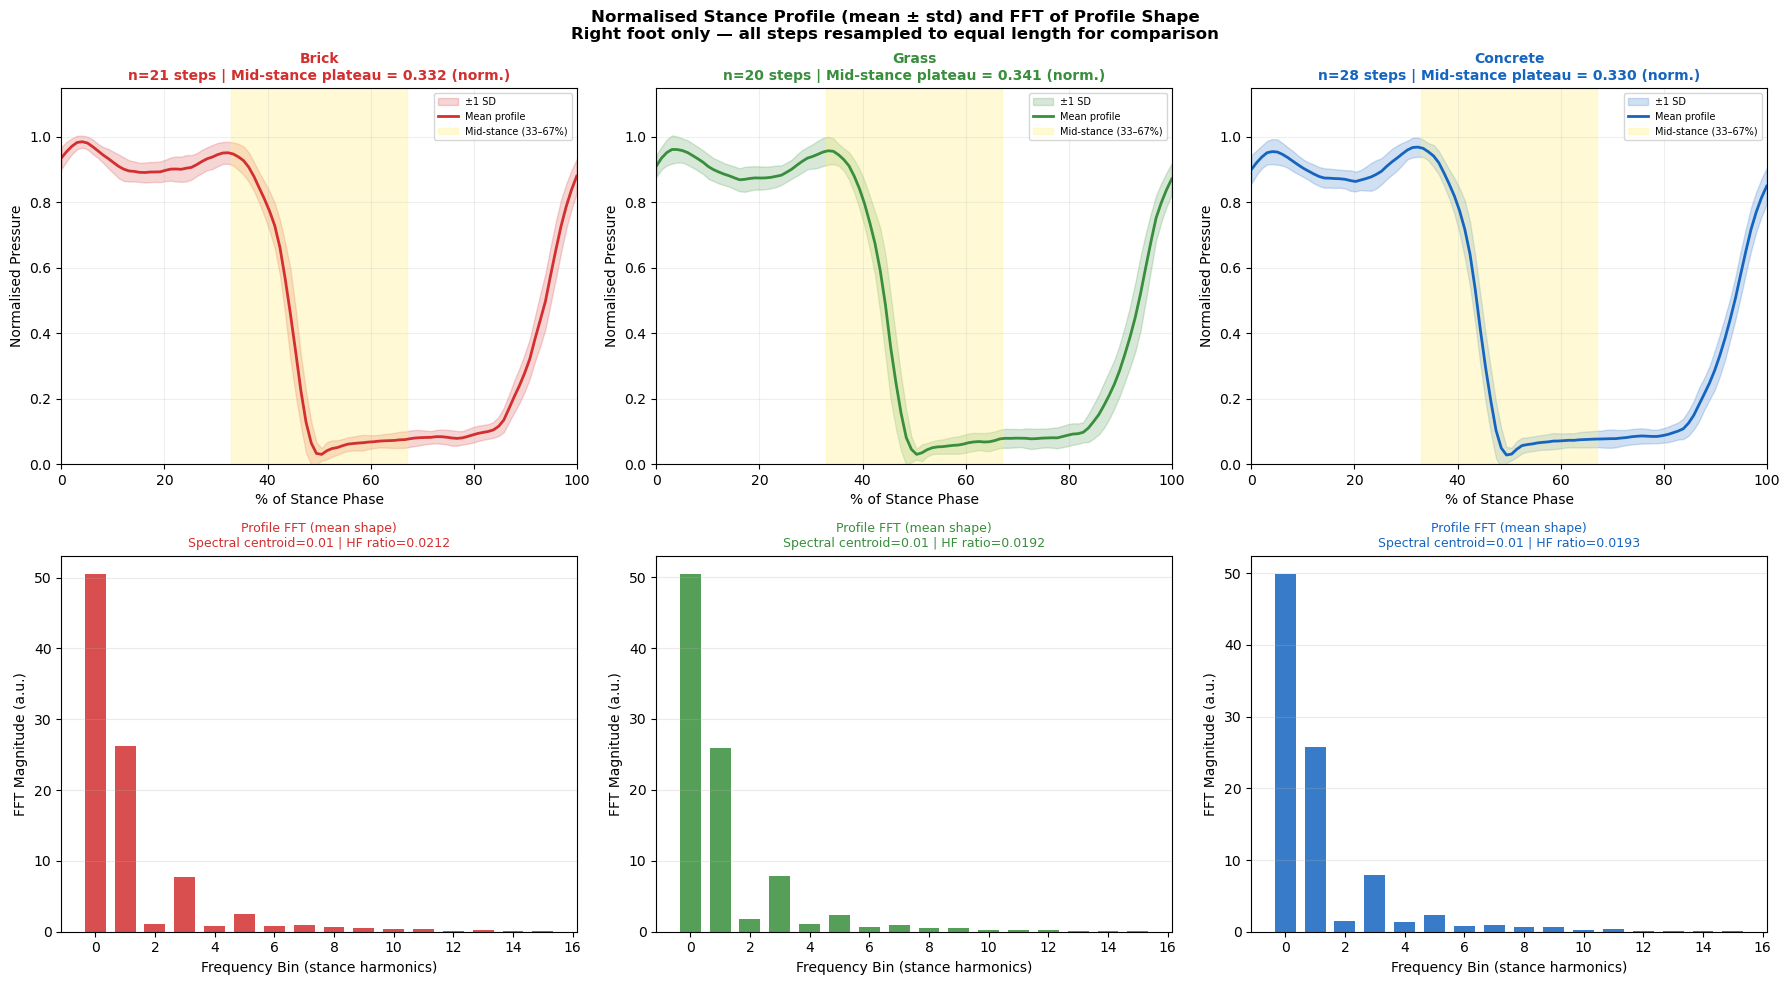

Saved → plot8_spectral_profiles.png


In [15]:
x_pct = np.linspace(0, 100, RESAMPLE_LEN)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Normalised Stance Profile (mean ± std) and FFT of Profile Shape\n'
             'Right foot only — all steps resampled to equal length for comparison',
             fontsize=12, fontweight='bold')

for col, surface in enumerate(SURFACES):
    profs = stance_profiles[surface]
    mean  = profs.mean(axis=0)
    std   = profs.std(axis=0)
    c     = COLORS[surface]
    n_steps = len(profs)

    # Mid-stance plateau region (33–67%)
    ms_mask   = (x_pct >= 33) & (x_pct <= 67)
    ms_plateau = mean[ms_mask].mean()

    # Top row — stance profile
    ax = axes[0][col]
    ax.fill_between(x_pct, mean - std, mean + std, color=c, alpha=0.2, label='±1 SD')
    ax.plot(x_pct, mean, color=c, lw=2, label='Mean profile')
    ax.axvspan(33, 67, color='#FFF176', alpha=0.3, label='Mid-stance (33–67%)')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.15)
    ax.set_title(
        f'{surface.capitalize()}\nn={n_steps} steps | Mid-stance plateau = {ms_plateau:.3f} (norm.)',
        fontsize=10, fontweight='bold', color=c)
    ax.set_ylabel('Normalised Pressure')
    ax.set_xlabel('% of Stance Phase')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

    # Bottom row — FFT magnitude
    ax2 = axes[1][col]
    F       = np.abs(fft(mean)[:RESAMPLE_LEN // 2])
    freqs   = np.arange(len(F))
    hf_ratio = F[10:].sum() / (F.sum() + 1e-9)
    centroid  = (freqs * F).sum() / (F.sum() + 1e-9) / RESAMPLE_LEN
    ax2.bar(freqs[:16], F[:16], color=c, alpha=0.85, width=0.7)
    ax2.set_title(
        f'Profile FFT (mean shape)\nSpectral centroid={centroid:.2f} | HF ratio={hf_ratio:.4f}',
        fontsize=9, color=c)
    ax2.set_xlabel('Frequency Bin (stance harmonics)')
    ax2.set_ylabel('FFT Magnitude (a.u.)')
    ax2.grid(axis='y', alpha=0.25)
    if F[1] == F[:16].max():
        ax2.text(1, F[1], 'loading', fontsize=7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('plot8_spectral_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot8_spectral_profiles.png')

---
## 📊 Plot 9 — Per-Surface Feature Summary (Statistical)

In [16]:
# Build per-step feature table
def extract_step_stats(df, surface, foot):
    peaks = find_step_peaks(df)
    rows  = []
    t     = df['time_sec'].values
    tp    = df['total_pressure'].values.astype(float)
    hp    = df['heel_pressure'].values.astype(float)
    fp    = df['fore_pressure'].values.astype(float)
    ay    = df['accel_y'].values.astype(float)

    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh = hp[p1:p2]; wf = fp[p1:p2]; wtp = tp[p1:p2]; way = ay[p1:p2]
        if len(wh) < 3: continue

        # Impact magnitude
        c_loc  = int(np.argmin(wh))
        hw     = min(int(0.15 * SAMPLING_HZ), len(way) - 1)
        impact = float(np.max(np.abs(way[max(0, c_loc-hw):c_loc+hw+1])))

        # Loading rate (from heel signal within step window)
        seg_h = wh
        hlo = int(np.argmin(seg_h))
        hill = seg_h[hlo:min(hlo + HILL_WIN, len(seg_h))]
        lr = np.nan
        if len(hill) >= 2:
            lps2, _ = find_peaks(hill, prominence=1)
            hhi2 = lps2[0] if len(lps2) else int(np.argmax(hill[1:])) + 1
            dp2 = float(hill[hhi2] - hill[0])
            if dp2 >= MIN_DP and hhi2 > 0:
                dt2 = hhi2 / SAMPLING_HZ
                lr = dp2 / dt2

        # Fore/heel ratio
        fhr = float(wf.mean() / (wh.mean() + 1e-9))

        # Step duration
        dur = t[p2-1] - t[p1]

        # Peak total
        ptp = float(wtp.max())

        # Heel impact pressure
        hip = float(wh.max())

        rows.append(dict(surface=surface, foot=foot,
                         impact_magnitude=impact,
                         loading_rate=lr,
                         fore_heel_ratio=fhr,
                         step_duration=dur,
                         peak_total_pressure=ptp,
                         heel_impact_pressure=hip))
    return pd.DataFrame(rows)

all_steps = pd.concat([
    extract_step_stats(datasets[s][f], s, f)
    for s in SURFACES for f in ['right', 'left']
], ignore_index=True)

print('\n=== Per-Surface Feature Summary ===')
print(all_steps.groupby('surface')[[
    'impact_magnitude','loading_rate','fore_heel_ratio',
    'step_duration','peak_total_pressure','heel_impact_pressure'
]].agg(['mean','std','median','count']).to_string())


=== Per-Surface Feature Summary ===
         impact_magnitude                             loading_rate                            fore_heel_ratio                           step_duration                        peak_total_pressure                           heel_impact_pressure                         
                     mean          std   median count         mean         std   median count            mean       std    median count          mean       std median count                mean         std  median count                 mean        std  median count
surface                                                                                                                                                                                                                                                                 
brick        19554.073171  1613.017427  19631.0    41  2410.907254  909.021095  2187.50    41        3.179057  0.501088  2.905752    41      1.100878  0.031642  1.104  

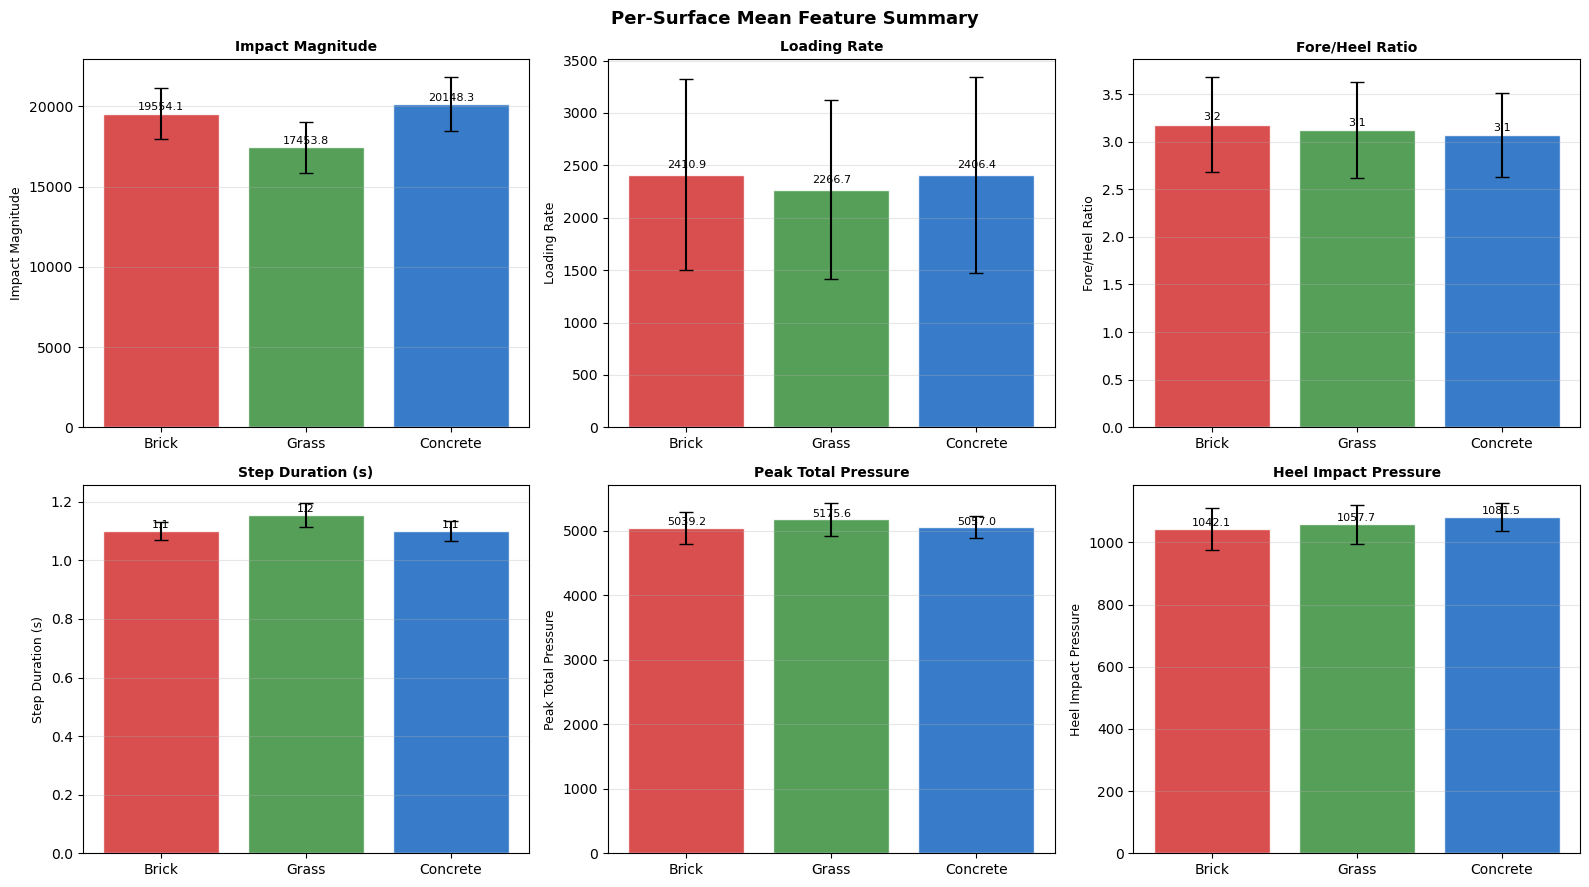

Saved → plot9_feature_summary.png


In [17]:
# Visual bar chart of mean features
feats = ['impact_magnitude','loading_rate','fore_heel_ratio',
         'step_duration','peak_total_pressure','heel_impact_pressure']
feat_labels = ['Impact Magnitude','Loading Rate',
               'Fore/Heel Ratio','Step Duration (s)',
               'Peak Total Pressure','Heel Impact Pressure']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Per-Surface Mean Feature Summary', fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flat, feats, feat_labels):
    grp = all_steps.groupby('surface')[feat]
    means = grp.mean()
    stds  = grp.std()
    for i, surf in enumerate(SURFACES):
        ax.bar(i, means.get(surf, 0), yerr=stds.get(surf, 0),
               color=COLORS[surf], alpha=0.85, capsize=5,
               edgecolor='white')
        ax.text(i, means.get(surf, 0) + stds.get(surf, 0) * 0.05,
                f'{means.get(surf, 0):.1f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(SURFACES)))
    ax.set_xticklabels(SURF_NAMES, fontsize=10)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot9_feature_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot9_feature_summary.png')

In [18]:
# ANOVA table
print('\n=== One-Way ANOVA across surfaces ===')
print(f'{"Feature":<30}  {"F":>8}  {"p-value":>12}  sig')
print('-' * 60)
for feat in feats:
    groups = [all_steps[all_steps['surface'] == s][feat].dropna().values
              for s in SURFACES]
    if all(len(g) > 1 for g in groups):
        F, p = f_oneway(*groups)
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'{feat:<30}  {F:>8.2f}  {p:>12.3e}  {sig}')
    else:
        print(f'{feat:<30}  {"nan":>8}  {"nan":>12}')


=== One-Way ANOVA across surfaces ===
Feature                                F       p-value  sig
------------------------------------------------------------
impact_magnitude                   33.14     1.961e-12  ***
loading_rate                        0.34     7.116e-01  
fore_heel_ratio                     0.64     5.273e-01  
step_duration                      32.67     2.682e-12  ***
peak_total_pressure                 4.64     1.128e-02  *
heel_impact_pressure                5.77     3.948e-03  **


---
## 🤖 Plot 10 — Confusion Matrix (ML Model Results)
> These cells recreate the Phase 1 and Phase 2 confusion matrices shown in the presentation using the same per-step feature data.

In [19]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import itertools

FEATURE_COLS = ['impact_magnitude','loading_rate','fore_heel_ratio',
                'step_duration','peak_total_pressure','heel_impact_pressure']

df_ml  = all_steps.dropna(subset=FEATURE_COLS + ['surface'])
X      = df_ml[FEATURE_COLS].values
y      = df_ml['surface'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.3f}\n')
print(classification_report(y_test, y_pred, target_names=SURF_NAMES))

Test Accuracy: 0.821

              precision    recall  f1-score   support

       Brick       0.70      0.88      0.78         8
       Grass       0.82      0.75      0.78        12
    Concrete       1.00      0.88      0.93         8

    accuracy                           0.82        28
   macro avg       0.84      0.83      0.83        28
weighted avg       0.84      0.82      0.82        28



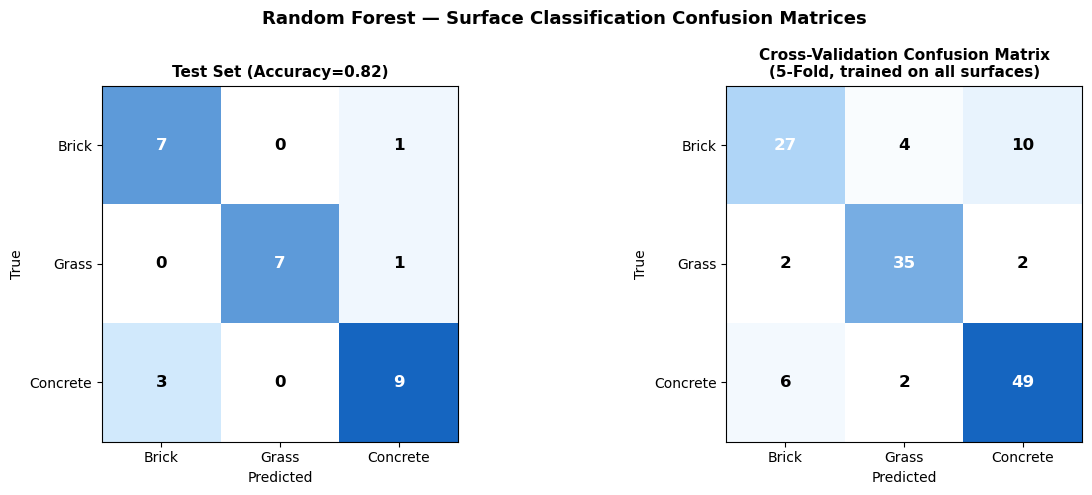

Saved → plot10_confusion_matrix.png


In [20]:
def plot_confusion_matrix(cm_arr, class_names, ax, title, normalize=True):
    if normalize:
        cm_arr = cm_arr.astype(float) / (cm_arr.sum(axis=1, keepdims=True) + 1e-9)

    from matplotlib.colors import LinearSegmentedColormap
    blues = LinearSegmentedColormap.from_list('blueish',
                ['#FFFFFF', '#BBDEFB', '#1565C0'], N=256)

    im = ax.imshow(cm_arr, interpolation='nearest', cmap=blues)
    ax.set_title(title, fontweight='bold', fontsize=11)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks); ax.set_xticklabels(class_names)
    ax.set_yticks(tick_marks); ax.set_yticklabels(class_names)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

    thresh = cm_arr.max() / 2.0
    for i, j in itertools.product(range(cm_arr.shape[0]), range(cm_arr.shape[1])):
        val = f'{cm_arr[i, j]:.2f}' if normalize else str(int(cm_arr[i, j]))
        ax.text(j, i, val, ha='center', va='center',
                color='white' if cm_arr[i, j] > thresh else 'black',
                fontsize=12, fontweight='bold')

# Cross-val confusion matrix
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv   = cross_val_predict(clf, X, y, cv=skf)
cm_test = confusion_matrix(y_test, y_pred, labels=SURFACES)
cm_cv   = confusion_matrix(y, y_cv, labels=SURFACES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest — Surface Classification Confusion Matrices',
             fontsize=13, fontweight='bold')

plot_confusion_matrix(cm_test.copy(), SURF_NAMES, ax1,
                      f'Test Set (Accuracy={accuracy_score(y_test,y_pred):.2f})',
                      normalize=False)
plot_confusion_matrix(cm_cv.copy(),   SURF_NAMES, ax2,
                      'Cross-Validation Confusion Matrix\n(5-Fold, trained on all surfaces)',
                      normalize=False)

plt.tight_layout()
plt.savefig('plot10_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot10_confusion_matrix.png')

---
## 🎨 Plot 11 — Step Timeline Prediction Strip

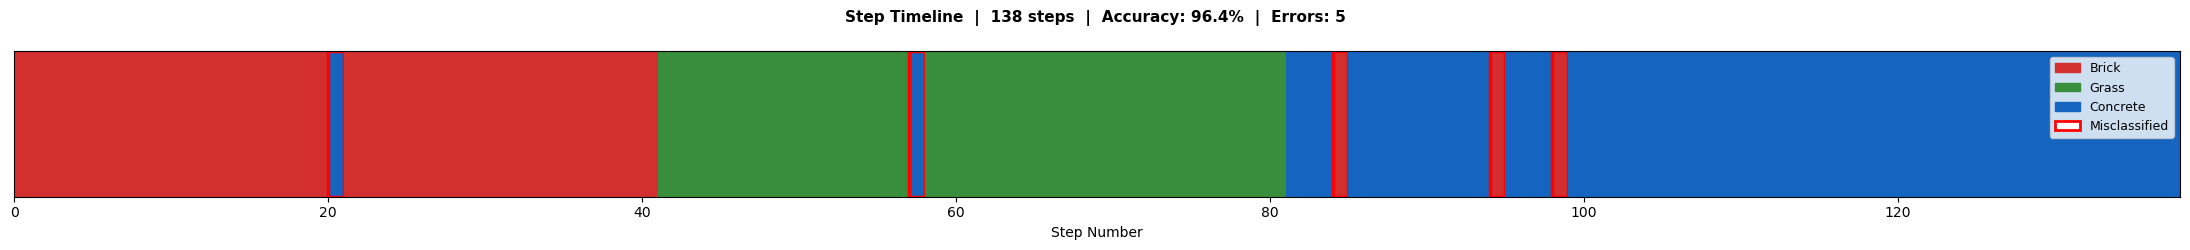

Saved → plot11_step_timeline.png


In [21]:
# Build a synthetic multi-surface walk by concatenating step feature rows
# (maintains the ground-truth order: brick → grass → concrete)
df_walk    = all_steps.copy().reset_index(drop=True)
X_walk     = df_walk[FEATURE_COLS].fillna(0).values
y_true     = df_walk['surface'].values
y_pred_w   = clf.predict(X_walk)

n_steps  = len(y_true)
accuracy = np.mean(y_true == y_pred_w)
errors   = np.sum(y_true != y_pred_w)

fig, ax = plt.subplots(figsize=(22, 2.5))
fig.suptitle(f'Step Timeline  |  {n_steps} steps  |  Accuracy: {accuracy*100:.1f}%  |  Errors: {errors}',
             fontsize=11, fontweight='bold')

for i, (true, pred) in enumerate(zip(y_true, y_pred_w)):
    facecolor = COLORS.get(pred, '#9E9E9E')
    edgecolor = 'red' if true != pred else facecolor
    lw        = 2.5  if true != pred else 0
    rect = plt.Rectangle((i, 0), 1, 1,
                          facecolor=facecolor, edgecolor=edgecolor, linewidth=lw)
    ax.add_patch(rect)

ax.set_xlim(0, n_steps)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Step Number')

legend_patches = [
    mpatches.Patch(color=COLORS['brick'],    label='Brick'),
    mpatches.Patch(color=COLORS['grass'],    label='Grass'),
    mpatches.Patch(color=COLORS['concrete'], label='Concrete'),
    mpatches.Patch(facecolor='white', edgecolor='red', linewidth=2, label='Misclassified'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('plot11_step_timeline.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → plot11_step_timeline.png')

---
## ✅ Summary
All 11 plots saved with uniform color scheme:
- 🔴 **Red (`#D32F2F`)** = Brick  
- 🟢 **Green (`#388E3C`)** = Grass  
- 🔵 **Blue (`#1565C0`)** = Concrete  

Files produced:
1. `plot1_timeseries_{surface}.png` (×3)
2. `plot2_heatmap_{surface}.png` (×3)
3. `plot3_step_segmentation.png`
4. `plot4_midstance_boxplots.png`
5. `plot5_midstance_segmentation.png`
6. `plot6a_loading_rate_signal.png`  +  `plot6b_loading_rate_boxplots.png`
7. `plot7_heel_strike.png`
8. `plot8_spectral_profiles.png`
9. `plot9_feature_summary.png`
10. `plot10_confusion_matrix.png`
11. `plot11_step_timeline.png`